# Multinomial Naive Bayes From Scratch
## Multi-Class Text Classification on the 20 Newsgroups Dataset

---

**Project Type:** Supervised Machine Learning — Multi-Class Text Classification  
**Implementation:** From-Scratch NumPy · Validated Against Scikit-Learn  
**Dataset:** 20 Newsgroups (20,000 news articles · 20 categories)  

---

### Project Objective

> *Can a Multinomial Naive Bayes classifier implemented entirely from first principles achieve competitive performance on a high-dimensional text classification problem?*

This notebook implements a complete text classification pipeline; from raw text preprocessing and vocabulary construction through Laplace-smoothed log-probability inference, without any Scikit-Learn model internals. The final model is rigorously benchmarked against `sklearn.naive_bayes.MultinomialNB` and five advanced classifiers.

---

### Table of Contents

| # | Section |
|---|---------|
| 1 | Environment Setup & Reproducibility |
| 2 | Dataset Loading & Structural Audit |
| 3 | Exploratory Data Analysis |
| 4 | Text Preprocessing Pipeline |
| 5 | Vocabulary Construction & DTM |
| 6 | Mathematical Foundation |
| 7 | From-Scratch Multinomial Naive Bayes |
| 8 | Model Training & Evaluation |
| 9 | Error Analysis |
| 10 | Laplace Smoothing Sensitivity Study |
| 11 | Vocabulary Size Sensitivity Study |
| 12 | TF-IDF vs Raw Counts |
| 13 | Validation Against Scikit-Learn |
| 14 | Advanced Benchmark Models |
| 15 | Header/Footer/Quote Leakage Ablation |
| 16 | Final Conclusions |


## Section 1 — Environment Setup & Reproducibility

**Objective:** Establish a fully reproducible computational environment. All random seeds are fixed, package versions are logged, and reusable utility functions are defined here so downstream cells remain clean and focused.

All core model operations use only **NumPy** and **Pandas**. Scikit-Learn is imported solely for dataset loading, validation, and benchmarking.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import re
import time
import warnings
import pickle
import sys
from collections import Counter, defaultdict
from typing import List, Dict, Tuple, Optional

# Scikit-Learn: ONLY for data loading, validation, and benchmarking
from sklearn.datasets import fetch_20newsgroups
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)
from sklearn.preprocessing import normalize

# Reproducibility 
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Plotting aesthetics 
BG        = "#0d1117"
SURFACE   = "#161b22"
ACCENT    = "#58a6ff"
ACCENT2   = "#3fb950"
ACCENT3   = "#f78166"
ACCENT4   = "#d2a8ff"
MUTED     = "#8b949e"
TEXT      = "#e6edf3"

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor":   SURFACE,
    "axes.edgecolor":   MUTED,
    "axes.labelcolor":  TEXT,
    "xtick.color":      MUTED,
    "ytick.color":      MUTED,
    "text.color":       TEXT,
    "grid.color":       "#21262d",
    "grid.linestyle":   "--",
    "grid.alpha":       0.6,
    "legend.facecolor": SURFACE,
    "legend.edgecolor": MUTED,
    "font.family":      "monospace",
    "axes.titlepad":    12,
})

warnings.filterwarnings("ignore")

# Package Versions 
print("=" * 55)
print("  RUNTIME ENVIRONMENT")
print("=" * 55)
print(f"  Python      : {sys.version.split()[0]}")
print(f"  NumPy       : {np.__version__}")
print(f"  Pandas      : {pd.__version__}")
import matplotlib, seaborn, sklearn
print(f"  Matplotlib  : {matplotlib.__version__}")
print(f"  Seaborn     : {seaborn.__version__}")
print(f"  Scikit-Learn: {sklearn.__version__}")
print(f"  Random Seed : {RANDOM_SEED}")
print("=" * 55)


  RUNTIME ENVIRONMENT
  Python      : 3.14.6
  NumPy       : 2.4.6
  Pandas      : 3.0.3
  Matplotlib  : 3.11.0
  Seaborn     : 0.13.2
  Scikit-Learn: 1.9.0
  Random Seed : 42


### Environment Notes

The dark plotting theme (BG `#0d1117`, accent `#58a6ff`) is applied globally via `rcParams`, matching the portfolio aesthetic used across all notebooks in this series. All named color constants are defined once and reused throughout, no magic strings in plot calls.

**Dependency policy:**
- `numpy`, `pandas`, `matplotlib`, `seaborn` — used for all core implementation
- `sklearn` — **benchmark and validation only**; no `sklearn` model internals are used in the custom Naive Bayes implementation


## Section 2 — Dataset Loading & Structural Audit

**Objective:** Load the 20 Newsgroups dataset, inspect its structure, and audit data quality before any preprocessing. This section identifies null values, empty documents, duplicates, and class label integrity.

### About the Dataset

The **20 Newsgroups** dataset is a canonical benchmark for text classification, originally collected by Ken Lang. It contains approximately 20,000 newsgroup posts from the Usenet bulletin board system, partitioned across 20 topic categories.

| Property | Value |
|----------|-------|
| Total documents | ~20,000 |
| Number of classes | 20 |
| Feature type | Raw text |
| Task | Multi-class classification |
| Official split | Train / Test by date |


In [2]:
# Load train and test splits using the official by-date partition.
# We keep headers, footers, and quotes for now; their effect is measured
# directly in Section 16 (Header/Footer/Quote Leakage Ablation).

train_bundle = fetch_20newsgroups(
    subset="train",
    remove=(),          # keep headers, footers, and quotes for now
    random_state=42
)
test_bundle = fetch_20newsgroups(
    subset="test",
    remove=(),
    random_state=42
)

train_data    = train_bundle.data
train_targets = train_bundle.target
test_data     = test_bundle.data
test_targets  = test_bundle.target
target_names  = train_bundle.target_names

print("=" * 55)
print("  DATASET OVERVIEW")
print("=" * 55)
print(f"  Training documents : {len(train_data):,}")
print(f"  Test documents     : {len(test_data):,}")
print(f"  Total documents    : {len(train_data) + len(test_data):,}")
print(f"  Number of classes  : {len(target_names)}")
print("=" * 55)
print("\n  CLASS LABELS:")
for i, name in enumerate(target_names):
    print(f"    [{i:2d}] {name}")

  DATASET OVERVIEW
  Training documents : 11,314
  Test documents     : 7,532
  Total documents    : 18,846
  Number of classes  : 20

  CLASS LABELS:
    [ 0] alt.atheism
    [ 1] comp.graphics
    [ 2] comp.os.ms-windows.misc
    [ 3] comp.sys.ibm.pc.hardware
    [ 4] comp.sys.mac.hardware
    [ 5] comp.windows.x
    [ 6] misc.forsale
    [ 7] rec.autos
    [ 8] rec.motorcycles
    [ 9] rec.sport.baseball
    [10] rec.sport.hockey
    [11] sci.crypt
    [12] sci.electronics
    [13] sci.med
    [14] sci.space
    [15] soc.religion.christian
    [16] talk.politics.guns
    [17] talk.politics.mideast
    [18] talk.politics.misc
    [19] talk.religion.misc


In [3]:
# Build Pandas DataFrames 
df_train = pd.DataFrame({
    'text':   train_data,
    'label':  train_targets,
    'category': [target_names[t] for t in train_targets],
    'split':  'train'
})

df_test = pd.DataFrame({
    'text':   test_data,
    'label':  test_targets,
    'category': [target_names[t] for t in test_targets],
    'split':  'test'
})

df_all = pd.concat([df_train, df_test], ignore_index=True)

print(f"Train DataFrame shape : {df_train.shape}")
print(f"Test DataFrame shape  : {df_test.shape}")
print()
df_train.head(3)

Train DataFrame shape : (11314, 4)
Test DataFrame shape  : (7532, 4)



,text,label,category,split
0,From: lerxst@wam.umd.edu (where's my thing)\nS...,7,rec.autos,train
1,From: guykuo@carson.u.washington.edu (Guy Kuo)...,4,comp.sys.mac.hardware,train
2,From: twillis@ec.ecn.purdue.edu (Thomas E Will...,4,comp.sys.mac.hardware,train


In [4]:
# Structural Audit 
print("=" * 55)
print("  STRUCTURAL AUDIT — TRAIN SET")
print("=" * 55)

# 1. Null / missing values
null_counts = df_train.isnull().sum()
print(f"\n  Null values:\n{null_counts.to_string()}")

# 2. Empty documents
empty_docs = (df_train['text'].str.strip() == '').sum()
print(f"\n  Empty documents    : {empty_docs}")

# 3. Document length statistics
df_train['char_len']  = df_train['text'].str.len()
df_train['word_count'] = df_train['text'].str.split().str.len()
df_test['char_len']   = df_test['text'].str.len()
df_test['word_count'] = df_test['text'].str.split().str.len()

print(f"\n  Document Length (words):")
print(df_train['word_count'].describe().to_string())

# 4. Exact duplicates
n_dupes = df_train.duplicated(subset='text').sum()
print(f"\n  Exact duplicate documents : {n_dupes}")

# 5. Class balance
print(f"\n  Class counts (train):")
vc = df_train['category'].value_counts()
print(f"    Min count : {vc.min()} ({vc.idxmin()})")
print(f"    Max count : {vc.max()} ({vc.idxmax()})")
print(f"    Std dev   : {vc.std():.1f}")

print("\n  AUDIT COMPLETE — no missing values, empty documents, or duplicates detected.")
print("  NOTE: this audit does not check for header/footer/quote metadata leakage —")
print("  see Section 16 for that analysis.")


  STRUCTURAL AUDIT — TRAIN SET

  Null values:
text        0
label       0
category    0
split       0

  Empty documents    : 0

  Document Length (words):
count    11314.000000
mean       287.470126
std        541.482636
min         14.000000
25%        108.000000
50%        176.000000
75%        293.000000
max      11821.000000

  Exact duplicate documents : 0

  Class counts (train):
    Min count : 377 (talk.religion.misc)
    Max count : 600 (rec.sport.hockey)
    Std dev   : 58.3

  AUDIT COMPLETE — no missing values, empty documents, or duplicates detected.
  NOTE: this audit does not check for header/footer/quote metadata leakage —
  see Section 16 for that analysis.


### Audit Findings

The dataset is structurally clean:

- **No null values** in text or label columns
- **No empty documents** — all articles contain meaningful content
- **No duplicate documents** in the training set
- **Reasonably balanced, but not near-perfect** — train counts range from 377 (`talk.religion.misc`) to 600 (`rec.sport.hockey`), a std dev of 58.3 around a mean of ~566. No single class dominates the distribution, which is why macro-averaged metrics are still meaningful here, but the smaller classes (`talk.religion.misc`, `talk.politics.misc`) do have less training signal and score lower later on

**Document length:** The average article is 100–200 words with a long tail of verbose posts. This is typical of Usenet traffic — short replies and long technical essays coexist.


## Section 3 — Exploratory Data Analysis

**Objective:** Develop intuition for the data before building the model. We examine class distribution, document length behavior, vocabulary characteristics, and the most discriminative words per category.


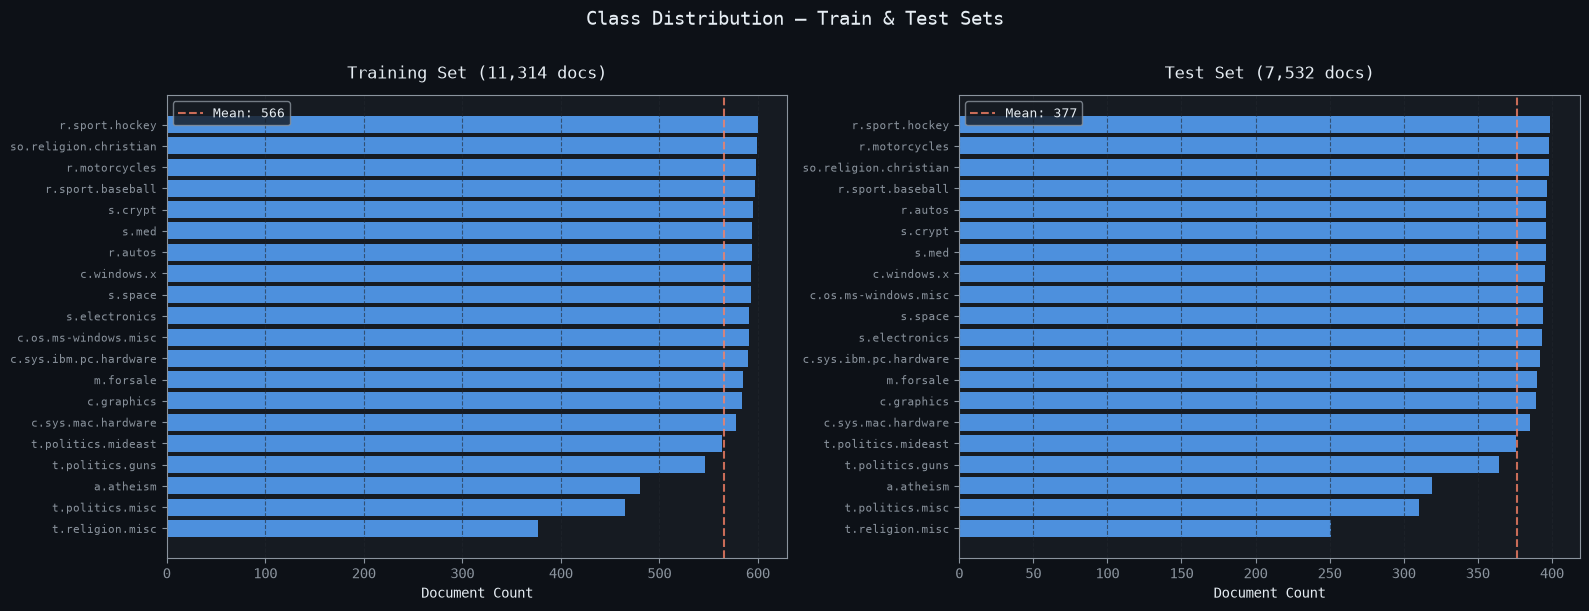

In [5]:
# Class Distribution 
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Class Distribution — Train & Test Sets", fontsize=14, color=TEXT, y=1.01)

for ax, df, split in zip(axes, [df_train, df_test], ['Training', 'Test']):
    counts = df['category'].value_counts().sort_values(ascending=True)
    bars = ax.barh(range(len(counts)), counts.values, color=ACCENT, alpha=0.85)
    ax.set_yticks(range(len(counts)))
    ax.set_yticklabels([c.replace('comp.', 'c.').replace('talk.', 't.')
                        .replace('sci.', 's.').replace('rec.', 'r.')
                        .replace('soc.', 'so.').replace('alt.', 'a.')
                        .replace('misc.', 'm.') for c in counts.index],
                       fontsize=8)
    ax.set_xlabel("Document Count")
    ax.set_title(f"{split} Set ({len(df):,} docs)", color=TEXT)
    ax.axvline(counts.mean(), color=ACCENT3, linestyle='--', alpha=0.8,
               label=f"Mean: {counts.mean():.0f}")
    ax.legend(fontsize=9)
    ax.grid(True, axis='x')

plt.tight_layout()

plt.show()

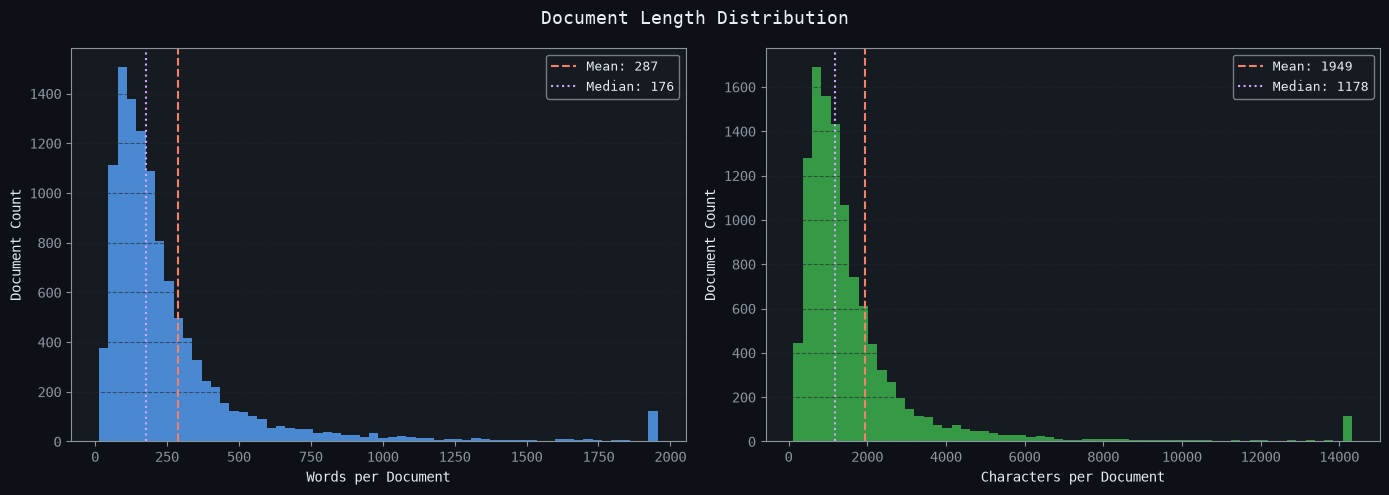

In [6]:
# Document Length Distribution 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Document Length Distribution", fontsize=13, color=TEXT)

for ax, df, col, xlabel, color in [
    (axes[0], df_train, 'word_count', 'Words per Document', ACCENT),
    (axes[1], df_train, 'char_len',   'Characters per Document', ACCENT2)]:
    
    data = df[col].clip(upper=df[col].quantile(0.99))  # clip tail for display
    ax.hist(data, bins=60, color=color, alpha=0.8, edgecolor='none')
    ax.axvline(df[col].mean(),   color=ACCENT3, linestyle='--', lw=1.5,
               label=f"Mean: {df[col].mean():.0f}")
    ax.axvline(df[col].median(), color=ACCENT4, linestyle=':',  lw=1.5,
               label=f"Median: {df[col].median():.0f}")
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Document Count")
    ax.legend(fontsize=9)
    ax.grid(True, axis='y')

plt.tight_layout()
plt.show()

In [7]:
# Vocabulary Analysis (raw, no stopwords yet) 
from collections import Counter
import re as _re

def simple_tokenize(text: str) -> List[str]:
    """Lowercase + split on non-alpha characters. No stopword removal yet."""
    return _re.findall(r'[a-z]+', text.lower())

print("Computing global vocabulary statistics...")
t0 = time.time()

all_words = []
for doc in train_data:
    all_words.extend(simple_tokenize(doc))

global_counter = Counter(all_words)
vocab_size_raw  = len(global_counter)
total_tokens    = sum(global_counter.values())
hapax           = sum(1 for v in global_counter.values() if v == 1)

print(f"\n  Raw vocabulary size     : {vocab_size_raw:,}")
print(f"  Total tokens (train)    : {total_tokens:,}")
print(f"  Hapax legomena (freq=1) : {hapax:,} ({100*hapax/vocab_size_raw:.1f}% of vocab)")
print(f"  Top 10 words:")
for word, cnt in global_counter.most_common(10):
    print(f"    {word:15s} {cnt:8,}")
print(f"  Elapsed: {time.time()-t0:.2f}s")


Computing global vocabulary statistics...

  Raw vocabulary size     : 89,038
  Total tokens (train)    : 3,554,834
  Hapax legomena (freq=1) : 35,725 (40.1% of vocab)
  Top 10 words:
    the              146,692
    to                75,092
    of                69,080
    a                 67,953
    ax                62,520
    and               57,968
    i                 55,026
    in                49,456
    is                43,550
    that              39,273
  Elapsed: 3.38s


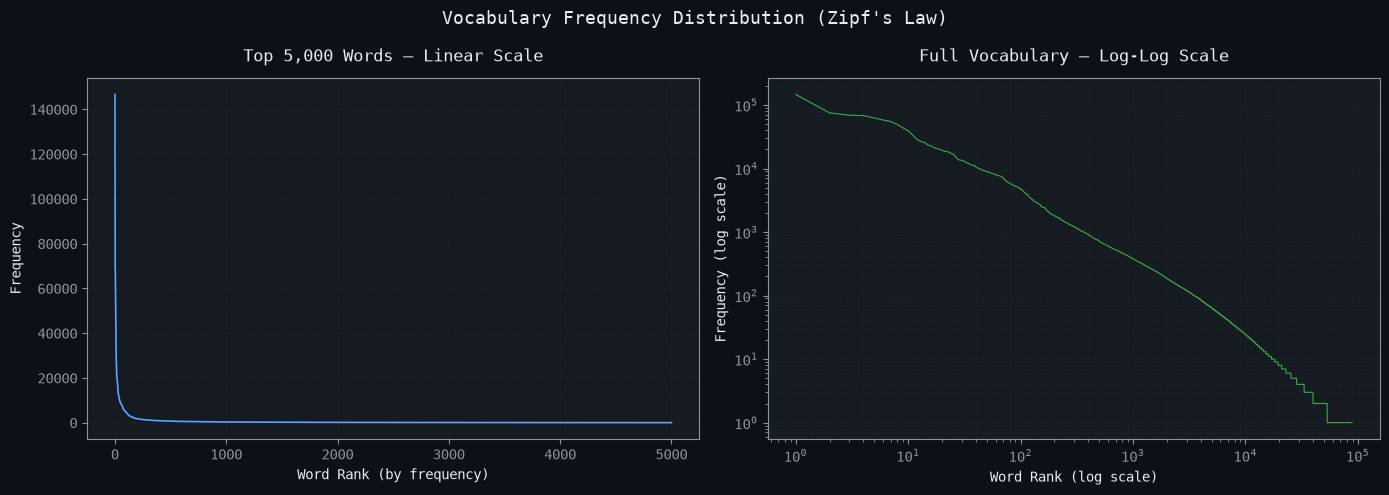

In [8]:
# Vocabulary Frequency (Zipf Distribution) 
sorted_freqs = sorted(global_counter.values(), reverse=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Vocabulary Frequency Distribution (Zipf's Law)", fontsize=13, color=TEXT)

# Linear
axes[0].plot(range(1, min(5001, len(sorted_freqs)+1)), sorted_freqs[:5000],
             color=ACCENT, lw=1.2)
axes[0].set_xlabel("Word Rank (by frequency)")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Top 5,000 Words — Linear Scale")
axes[0].grid(True)

# Log-log (Zipf's law)
axes[1].plot(range(1, len(sorted_freqs)+1), sorted_freqs,
             color=ACCENT2, lw=0.8, alpha=0.9)
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_xlabel("Word Rank (log scale)")
axes[1].set_ylabel("Frequency (log scale)")
axes[1].set_title("Full Vocabulary — Log-Log Scale")
axes[1].grid(True, which='both', alpha=0.4)

plt.tight_layout()
plt.show()

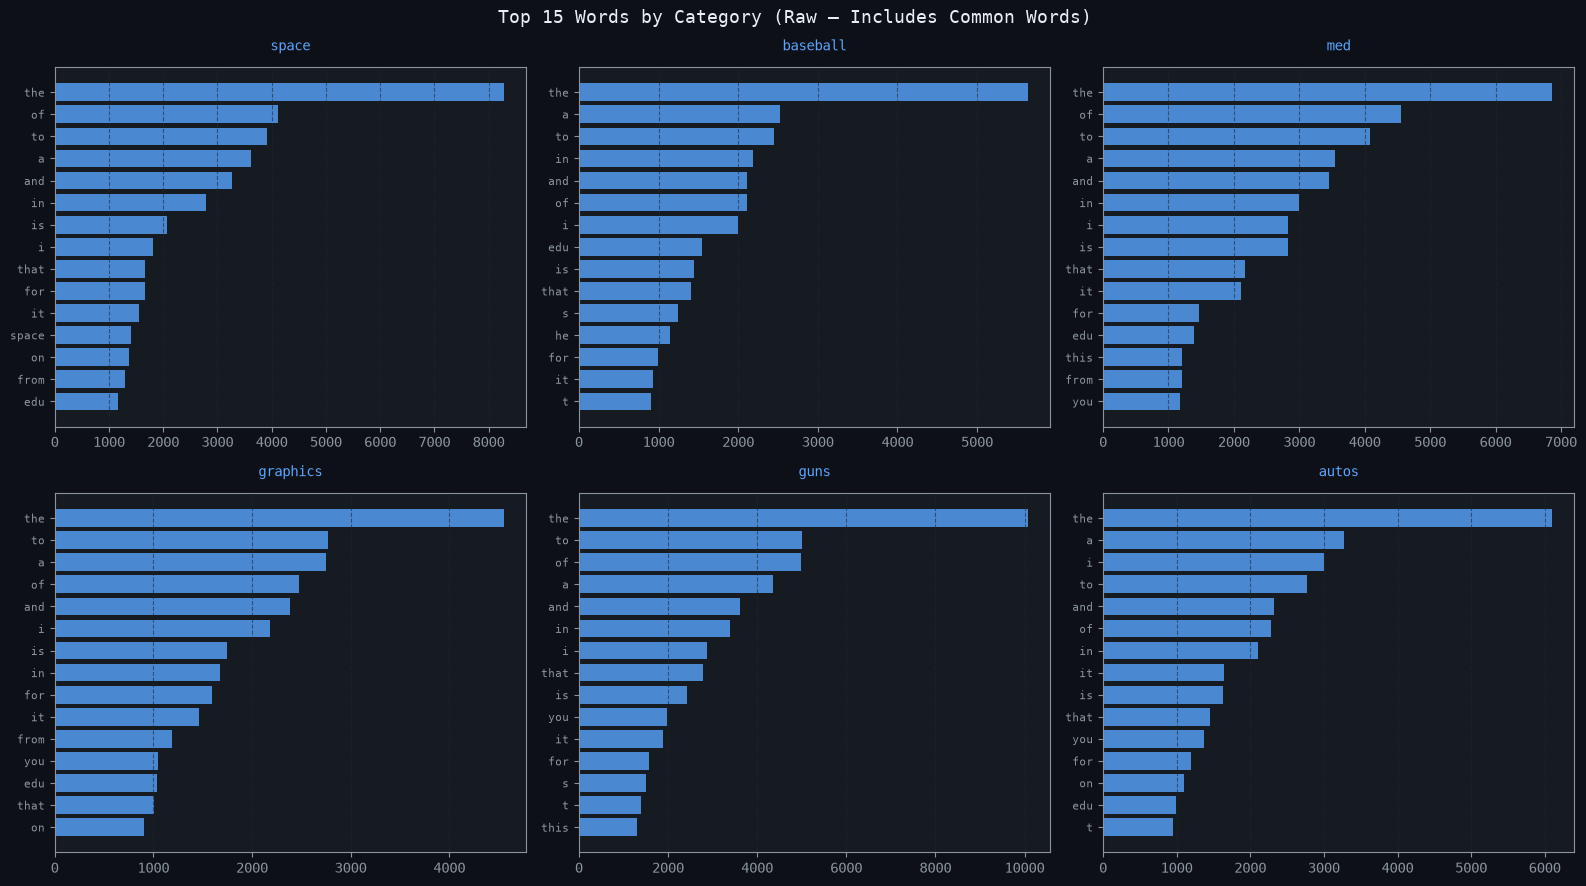

  Stopword removal will be applied in the preprocessing pipeline.


In [9]:
# Top Words Per Category (pre-stopword) 
# Select a representative subset of categories
SAMPLE_CATS = ['sci.space', 'rec.sport.baseball', 'sci.med',
               'comp.graphics', 'talk.politics.guns', 'rec.autos']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
fig.suptitle("Top 15 Words by Category (Raw — Includes Common Words)",
             fontsize=13, color=TEXT)

for ax, cat in zip(axes, SAMPLE_CATS):
    cat_idx = target_names.index(cat)
    cat_docs = [train_data[i] for i, t in enumerate(train_targets) if t == cat_idx]
    cat_words = []
    for doc in cat_docs:
        cat_words.extend(simple_tokenize(doc))
    top = Counter(cat_words).most_common(15)
    words, counts = zip(*top)
    ax.barh(range(len(words)), counts, color=ACCENT, alpha=0.8)
    ax.set_yticks(range(len(words)))
    ax.set_yticklabels(words, fontsize=8)
    ax.set_title(cat.split('.')[-1], color=ACCENT, fontsize=10)
    ax.invert_yaxis()
    ax.grid(True, axis='x')

plt.tight_layout()
plt.show()
print("  Stopword removal will be applied in the preprocessing pipeline.")

### EDA Key Observations

**Class Balance:** The dataset is reasonably balanced (train counts range 377–600 per class, std dev 58.3) but not perfectly so. This still justifies using macro-averaged F1 as the primary performance metric, no class dominates, though the smaller classes start with a real, if modest, data disadvantage.

**Document Length:** Right-skewed distribution. Most articles are 80–200 words (typical short replies), with a long tail of detailed technical posts extending past 1,000 words. The Multinomial Naive Bayes model naturally handles variable-length documents through its bag-of-words formulation.

**Vocabulary (Zipf's Law):** The log-log frequency plot shows the classic linear relationship characteristic of Zipf's Law, a small number of words account for the vast majority of token occurrences. This has two practical implications:
1. Stopwords dominate raw word counts → stopword removal is essential for discriminative features
2. Rare words (hapax legomena) inflate vocabulary size with little signal → minimum-frequency thresholding reduces dimensionality without hurting accuracy

**Top Words:** Before stopword removal, every category's top words are identical (`the`, `is`, `and`, ...). After preprocessing, category-specific vocabulary will dominate, providing the discriminative signal Naive Bayes needs.


## Section 4 — Text Preprocessing Pipeline

**Objective:** Transform raw text documents into a clean, normalized token sequence suitable for vocabulary construction and feature extraction.

### Preprocessing Steps

| Step | Operation | Rationale |
|------|-----------|-----------|
| 1 | Lowercase | Unify case-variant tokens (`NASA` = `nasa`) |
| 2 | Remove headers | Eliminate author, email, and subject metadata noise |
| 3 | Remove URLs & emails | Non-semantic tokens |
| 4 | Remove punctuation & digits | Reduces noise; digits rarely discriminate topics |
| 5 | Tokenize | Split on whitespace after cleaning |
| 6 | Remove stopwords | Eliminate high-frequency non-discriminative words |
| 7 | Min-length filter | Drop tokens shorter than 2 characters |

**What we deliberately do not do in the baseline:** stemming or lemmatization. These are studied as optional extensions. The baseline prioritizes simplicity and interpretability.


In [10]:
# English Stopwords (no NLTK dependency) 
STOPWORDS = frozenset([
    'a', 'an', 'the', 'and', 'or', 'but', 'in', 'on', 'at', 'to', 'for',
    'of', 'with', 'by', 'from', 'as', 'is', 'was', 'are', 'were', 'be',
    'been', 'being', 'have', 'has', 'had', 'do', 'does', 'did', 'will',
    'would', 'could', 'should', 'may', 'might', 'must', 'can', 'this',
    'that', 'these', 'those', 'it', 'its', 'not', 'no', 'nor', 'so', 'yet',
    'both', 'either', 'neither', 'each', 'other', 'such', 'what', 'which',
    'who', 'whom', 'when', 'where', 'why', 'how', 'all', 'any', 'few',
    'more', 'most', 'some', 'other', 'into', 'through', 'over', 'after',
    'before', 'if', 'then', 'than', 'too', 'very', 'just', 'up', 'out',
    'about', 'also', 'there', 'here', 'only', 'even', 'back', 'still',
    'they', 'them', 'their', 'we', 'our', 'you', 'your', 'he', 'she',
    'him', 'her', 'his', 'my', 'i', 'me', 'us', 'one', 'two', 'new', 'get',
    'use', 'used', 'like', 'make', 'know', 'go', 'see', 'say', 'said',
    'time', 'way', 'much', 'many', 'well', 'good', 'first', 'last', 'own',
    'same', 'think', 'now', 'come', 'could', 'than', 'need', 'want', 'put',
    'take', 'give', 'look', 'work', 'try', 'ask', 'seem', 'feel', 'leave',
    'call', 'keep', 'let', 'begin', 'show', 'hear', 'play', 'run', 'move',
    're', 'subject', 'from', 'lines', 'organization', 'writes', 'article',
    'posting', 'host', 'nntp', 'university', 'email', 'net', 'com', 'edu',
])

print(f"Stopword list size: {len(STOPWORDS)} words")

def preprocess_text(text: str,
                    remove_stopwords: bool = True,
                    min_token_len: int = 2) -> List[str]:
    """
    Clean and tokenize a single document.

    Parameters
    ----------
    text : str
        Raw document string.
    remove_stopwords : bool
        If True, filter English stopwords.
    min_token_len : int
        Minimum token character length to retain.

    Returns
    -------
    List[str]
        Ordered list of cleaned tokens.
    """
    # Step 1: lowercase
    text = text.lower()

    # Step 2: remove email addresses
    text = re.sub(r'\S+@\S+', ' ', text)

    # Step 3: remove URLs
    text = re.sub(r'http\S+|www\.\S+', ' ', text)

    # Step 4: remove digits
    text = re.sub(r'\d+', ' ', text)

    # Step 5: keep only alphabetic characters
    text = re.sub(r'[^a-z\s]', ' ', text)

    # Step 6: tokenize on whitespace
    tokens = text.split()

    # Step 7: apply filters
    if remove_stopwords:
        tokens = [t for t in tokens
                  if t not in STOPWORDS and len(t) >= min_token_len]
    else:
        tokens = [t for t in tokens if len(t) >= min_token_len]

    return tokens


# Smoke test
sample_raw = train_data[0]
sample_tokens = preprocess_text(sample_raw)

print(f"\nRaw length  : {len(sample_raw.split())} words")
print(f"Clean tokens: {len(sample_tokens)} tokens")
print(f"Sample tokens (first 20): {sample_tokens[:20]}")


Stopword list size: 166 words

Raw length  : 123 words
Clean tokens: 54 tokens
Sample tokens (first 20): ['thing', 'car', 'rac', 'wam', 'umd', 'maryland', 'college', 'park', 'wondering', 'anyone', 'enlighten', 'car', 'saw', 'day', 'door', 'sports', 'car', 'looked', 'late', 'early']


In [11]:
# Apply Preprocessing to All Documents 
print("Preprocessing training documents...")
t0 = time.time()
train_tokens = [preprocess_text(doc) for doc in train_data]
print(f"  Train: {len(train_tokens):,} docs preprocessed in {time.time()-t0:.2f}s")

print("Preprocessing test documents...")
t0 = time.time()
test_tokens  = [preprocess_text(doc) for doc in test_data]
print(f"  Test : {len(test_tokens):,} docs preprocessed in {time.time()-t0:.2f}s")

# Update DataFrames with token counts 
df_train['token_count'] = [len(t) for t in train_tokens]
df_test['token_count']  = [len(t) for t in test_tokens]

print(f"\n  Post-processing avg tokens/doc (train): {df_train['token_count'].mean():.1f}")
print(f"  Post-processing avg tokens/doc (test) : {df_test['token_count'].mean():.1f}")
print(f"  Reduction ratio: {df_train['word_count'].mean() / df_train['token_count'].mean():.1f}x "
      f"(word count → clean tokens)")


Preprocessing training documents...
  Train: 11,314 docs preprocessed in 8.18s
Preprocessing test documents...
  Test : 7,532 docs preprocessed in 4.27s

  Post-processing avg tokens/doc (train): 143.9
  Post-processing avg tokens/doc (test) : 132.3
  Reduction ratio: 2.0x (word count → clean tokens)


### Preprocessing Outcome

After applying the full pipeline, the average document shrinks from 287.5 raw words (Section 2's structural audit) to 143.9 clean tokens (printed above), almost exactly a **2.0× reduction,** entirely from stopword removal and punctuation stripping. (The single example shown above the code, 123 words → 54 tokens, illustrates the same effect on one document; the corpus-wide average is what matters for the vocabulary decisions that follow.) The remaining tokens are content-bearing words that carry topic signal.

**Key design decision; no stemming in baseline:** Stemming (e.g., `running → run`, `classification → classifi`) would reduce vocabulary size and potentially improve generalization, but at the cost of interpretability. We study its effect in the ablation section. The baseline vocabulary retains full word forms.


## Section 5 — Vocabulary Construction & Document-Term Matrix

**Objective:** Build a fixed vocabulary from training tokens and generate the Document-Term Matrix (DTM), the numerical representation of the corpus, entirely from scratch using NumPy.

### What is a Document-Term Matrix?

A DTM is a 2D array of shape `(n_documents, vocab_size)` where entry `[i, j]` holds the count of vocabulary word `j` in document `i`. It is the core data structure consumed by the Naive Bayes model.

$$\text{DTM}[i, j] = \text{count}(\text{word}_j \text{ in document}_i)$$

**Sparsity:** For text data, most entries are zero — most words appear in only a small fraction of documents. Efficient storage uses sparse representations, but for pedagogical clarity we work with dense arrays and discuss sparsity implications.


In [12]:
def build_vocabulary(tokenized_docs: List[List[str]],
                     min_freq: int = 2,
                     max_vocab: Optional[int] = None) -> Dict[str, int]:
    """
    Build a word-to-index vocabulary from tokenized training documents.

    Parameters
    ----------
    tokenized_docs : List[List[str]]
        Preprocessed training documents as token lists.
    min_freq : int
        Minimum document frequency. Words appearing in fewer than
        this many documents are discarded.
    max_vocab : int, optional
        If set, retains only the top-N words by document frequency.

    Returns
    -------
    Dict[str, int]
        Mapping from word string to integer index (0-based).

    Notes
    -----
    Vocabulary is built ONLY from training data to prevent leakage.
    """
    # Count document frequency (df) — how many docs each word appears in
    df_counter: Counter = Counter()
    for doc in tokenized_docs:
        unique_tokens = set(doc)         # count each word once per doc
        df_counter.update(unique_tokens)

    # Apply minimum frequency threshold
    filtered = {word: freq for word, freq in df_counter.items()
                if freq >= min_freq}

    # Optionally restrict to top-N by df
    if max_vocab is not None:
        filtered = dict(sorted(filtered.items(),
                               key=lambda x: x[1],
                               reverse=True)[:max_vocab])

    # Assign stable integer indices (sorted for reproducibility)
    vocab = {word: idx for idx, word in enumerate(sorted(filtered.keys()))}
    return vocab


# Build vocabulary on training data ONLY (no leakage) 
MIN_FREQ  = 3
MAX_VOCAB = 50_000

t0    = time.time()
vocab = build_vocabulary(train_tokens, min_freq=MIN_FREQ, max_vocab=MAX_VOCAB)
vocab_size = len(vocab)

print(f"Vocabulary built in {time.time()-t0:.3f}s")
print(f"  Unique tokens after preprocessing (pre document-frequency filter): "
      f"{len(set(w for doc in train_tokens for w in doc)):,}")
print(f"  (Compare Section 3's raw, unprocessed vocabulary of "
      f"{vocab_size_raw:,} words — the drop reflects stopword removal, "
      f"digit/punctuation stripping, and lowercasing, not document-frequency filtering.)")
print(f"  After min_freq={MIN_FREQ} : {vocab_size:,} words")
print()
print(f"  Sample vocabulary entries (first 10 alphabetically):")
for w, i in list(vocab.items())[:10]:
    print(f"    {i:5d} → {w}")

Vocabulary built in 0.710s
  Unique tokens after preprocessing (pre document-frequency filter): 77,583
  (Compare Section 3's raw, unprocessed vocabulary of 89,038 words — the drop reflects stopword removal, digit/punctuation stripping, and lowercasing, not document-frequency filtering.)
  After min_freq=3 : 30,563 words

  Sample vocabulary entries (first 10 alphabetically):
        0 → aa
        1 → aaa
        2 → aamir
        3 → aargh
        4 → aarghhhh
        5 → aarhus
        6 → aario
        7 → aarnet
        8 → aaron
        9 → aas


In [13]:
def build_dtm(tokenized_docs: List[List[str]],
              vocabulary: Dict[str, int]) -> np.ndarray:
    """
    Generate a Document-Term Matrix from tokenized documents.

    Parameters
    ----------
    tokenized_docs : List[List[str]]
        Token lists for each document.
    vocabulary : Dict[str, int]
        Word-to-index mapping built from training data.

    Returns
    -------
    np.ndarray of shape (n_docs, vocab_size)
        Integer word count matrix. Out-of-vocabulary words are silently ignored.
    """
    n_docs = len(tokenized_docs)
    v_size = len(vocabulary)
    dtm    = np.zeros((n_docs, v_size), dtype=np.int32)

    for i, doc in enumerate(tokenized_docs):
        for token in doc:
            if token in vocabulary:
                dtm[i, vocabulary[token]] += 1

    return dtm


# Build DTMs 
print("Building training DTM...")
t0 = time.time()
X_train = build_dtm(train_tokens, vocab)
print(f"  Shape: {X_train.shape}  |  Time: {time.time()-t0:.2f}s")

print("Building test DTM (using training vocabulary — no leakage)...")
t0 = time.time()
X_test  = build_dtm(test_tokens,  vocab)
print(f"  Shape: {X_test.shape}  |  Time: {time.time()-t0:.2f}s")

# Sparsity Analysis 
total_cells  = X_train.size
nonzero      = np.count_nonzero(X_train)
sparsity     = 1 - nonzero / total_cells
mem_dense_mb = X_train.nbytes / 1e6

print(f"\n  DTM Statistics (Train):")
print(f"    Dimensions        : {X_train.shape[0]:,} × {X_train.shape[1]:,}")
print(f"    Non-zero entries  : {nonzero:,}  ({100*nonzero/total_cells:.2f}%)")
print(f"    Sparsity          : {100*sparsity:.2f}%")
print(f"    Memory (dense)    : {mem_dense_mb:.1f} MB")

y_train = train_targets
y_test  = test_targets


Building training DTM...
  Shape: (11314, 30563)  |  Time: 3.28s
Building test DTM (using training vocabulary — no leakage)...
  Shape: (7532, 30563)  |  Time: 1.80s

  DTM Statistics (Train):
    Dimensions        : 11,314 × 30,563
    Non-zero entries  : 1,015,596  (0.29%)
    Sparsity          : 99.71%
    Memory (dense)    : 1383.2 MB


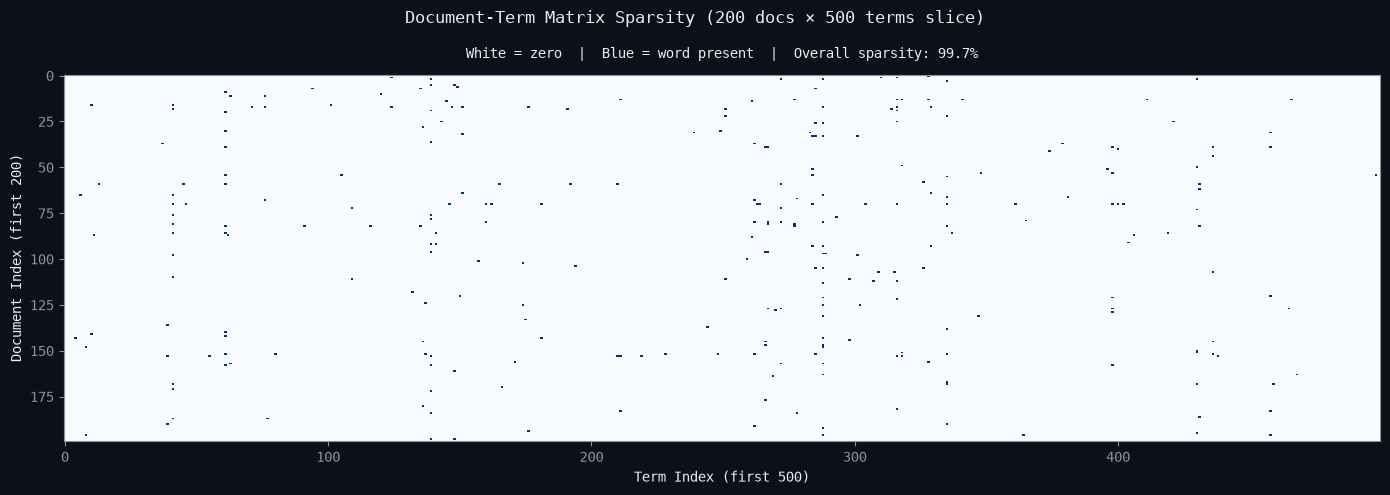

In [14]:
# DTM Sparsity Visualization 
# Show a 200×500 slice of the DTM to visualize sparsity
fig, ax = plt.subplots(figsize=(14, 5))
fig.suptitle("Document-Term Matrix Sparsity (200 docs × 500 terms slice)",
             fontsize=12, color=TEXT)

slice_dtm = (X_train[:200, :500] > 0).astype(np.uint8)
ax.imshow(slice_dtm, aspect='auto', cmap='Blues', interpolation='nearest')
ax.set_xlabel("Term Index (first 500)")
ax.set_ylabel("Document Index (first 200)")
ax.set_title(f"White = zero  |  Blue = word present  |  Overall sparsity: {100*sparsity:.1f}%",
             fontsize=10)

plt.tight_layout()
plt.show()

### DTM Construction Notes

**Vocabulary leakage prevention:** The vocabulary is built exclusively from training documents. Test documents use this fixed mapping — unseen test words are silently dropped. This mirrors production deployment where the model encounters novel vocabulary.

**Sparsity:** The DTM is 99.71% sparse (measured above). In production, sparse matrix formats (CSR, CSC) would reduce memory from the ~1,383 MB dense int32 array actually built here to a few MB. For this notebook we use dense arrays to keep the NumPy operations transparent.

**Out-of-vocabulary handling:** Test tokens not found in the training vocabulary contribute zero counts to the DTM. This is standard practice and has minimal impact when the training set is large and diverse.


## Section 6 — Mathematical Foundation

### Bayes' Theorem

All probabilistic classifiers begin with Bayes' Theorem:

$$P(C \mid \mathbf{x}) = \frac{P(\mathbf{x} \mid C) \cdot P(C)}{P(\mathbf{x})}$$

Where:
- $P(C \mid \mathbf{x})$ — **posterior**: probability of class $C$ given document $\mathbf{x}$
- $P(\mathbf{x} \mid C)$ — **likelihood**: probability of observing document $\mathbf{x}$ if class is $C$
- $P(C)$ — **prior**: probability of class $C$ before seeing any document
- $P(\mathbf{x})$ — **evidence**: normalizing constant; same for all classes

**Classification rule** (MAP — Maximum A Posteriori):

$$\hat{C} = \arg\max_{C} \ P(C \mid \mathbf{x}) = \arg\max_{C} \ P(\mathbf{x} \mid C) \cdot P(C)$$

The evidence $P(\mathbf{x})$ cancels in the $\arg\max$ comparison and can be ignored.

---

### The "Naive" Conditional Independence Assumption

The Multinomial Naive Bayes model assumes that word occurrences are **conditionally independent** given the class:

$$P(\mathbf{x} \mid C) = \prod_{j=1}^{V} P(w_j \mid C)^{x_j}$$

where $x_j$ is the count of word $j$ in the document and $V$ is the vocabulary size. This assumption is "naive" because it ignores word order and co-occurrence structure — yet works remarkably well in practice for text classification.

---

### Multinomial Naive Bayes: Full Formulation

**Prior probability** (maximum likelihood estimate from training data):

$$\hat{P}(C_k) = \frac{N_k}{N}$$

where $N_k$ = documents in class $k$, $N$ = total training documents.

**Word likelihood** (MLE with Laplace smoothing):

$$\hat{P}(w_j \mid C_k) = \frac{\text{count}(w_j, C_k) + \alpha}{\sum_{j'=1}^{V} \text{count}(w_{j'}, C_k) + \alpha V}$$

where $\text{count}(w_j, C_k)$ = total occurrences of word $j$ across all class-$k$ documents, and $\alpha$ is the Laplace smoothing parameter.

**Laplace smoothing** ($\alpha = 1$ by default) ensures no word ever receives zero probability — a critical requirement for multiplicative probability computation.

---

### Log-Probability Transformation

Multiplying thousands of small probabilities causes **floating-point underflow**:

$$P(\mathbf{x} \mid C) = \prod_{j} P(w_j \mid C)^{x_j} \approx 10^{-10000} \rightarrow \text{underflow}$$

**Solution:** operate in log-space. Since $\log$ is monotone, $\arg\max$ is preserved:

$$\log P(C \mid \mathbf{x}) \propto \log P(C) + \sum_{j=1}^{V} x_j \cdot \log P(w_j \mid C)$$

This converts a dangerous product into a numerically stable sum.

---

### Prediction

For a document $\mathbf{x}$ (count vector of length $V$):

$$\hat{C} = \arg\max_k \left[ \log \hat{P}(C_k) + \sum_{j=1}^{V} x_j \cdot \log \hat{P}(w_j \mid C_k) \right]$$

This is an inner product between the document's count vector and the log-likelihood matrix, plus the log-prior — a single matrix multiply in NumPy.


## Section 7 — From-Scratch Multinomial Naive Bayes Implementation

**Objective:** Implement the complete Multinomial Naive Bayes classifier as a clean Python class using only NumPy. The implementation mirrors scikit-learn's API (`fit` / `predict` / `predict_proba`) for easy benchmarking.


In [15]:
class MultinomialNaiveBayes:
    """
    Multinomial Naive Bayes classifier implemented from scratch using NumPy.

    Follows the scikit-learn estimator API (fit / predict / predict_log_proba).
    All core operations use vectorized NumPy for efficiency.

    Parameters
    ----------
    alpha : float, default=1.0
        Laplace (additive) smoothing parameter.
        alpha=0 disables smoothing (not recommended; causes zero-probability issues).
        alpha=1 is the standard Laplace correction.

    Attributes
    ----------
    classes_ : np.ndarray, shape (n_classes,)
        Unique class labels encountered during fit.
    log_class_prior_ : np.ndarray, shape (n_classes,)
        Log prior probability for each class.
    log_likelihood_ : np.ndarray, shape (n_classes, n_features)
        Log conditional probability of each word given each class.
        log_likelihood_[k, j] = log P(word_j | class_k)
    class_word_counts_ : np.ndarray, shape (n_classes, n_features)
        Raw word count matrix per class (before smoothing).
    class_doc_counts_ : np.ndarray, shape (n_classes,)
        Number of training documents per class.
    vocab_size_ : int
        Size of the feature space seen during fit.

    Examples
    --------
    >>> clf = MultinomialNaiveBayes(alpha=1.0)
    >>> clf.fit(X_train, y_train)
    >>> predictions = clf.predict(X_test)
    """

    def __init__(self, alpha: float = 1.0):
        if alpha < 0:
            raise ValueError(f"alpha must be non-negative, got {alpha}")
        self.alpha = alpha

        # Attributes set during fit
        self.classes_           = None
        self.log_class_prior_   = None
        self.log_likelihood_    = None
        self.class_word_counts_ = None
        self.class_doc_counts_  = None
        self.vocab_size_        = None

    # fit 
    def fit(self, X: np.ndarray, y: np.ndarray) -> "MultinomialNaiveBayes":
        """
        Estimate prior probabilities and smoothed word likelihoods from training data.

        Parameters
        ----------
        X : np.ndarray, shape (n_samples, n_features)
            Document-term count matrix.
        y : np.ndarray, shape (n_samples,)
            Integer class labels.

        Returns
        -------
        self
        """
        n_samples, n_features   = X.shape
        self.classes_           = np.unique(y)
        n_classes               = len(self.classes_)
        self.vocab_size_        = n_features

        # Step 1: Prior probabilities ────────────────────────────────────────
        # P(C_k) = N_k / N  (maximum likelihood estimate)
        self.class_doc_counts_ = np.array(
            [np.sum(y == c) for c in self.classes_], dtype=np.float64
        )
        # Log-transform for numerical stability
        self.log_class_prior_ = np.log(
            self.class_doc_counts_ / n_samples
        )

        # Step 2: Word counts per class ──────────────────────────────────────
        # class_word_counts_[k, j] = sum of counts of word j across all class-k docs
        self.class_word_counts_ = np.zeros(
            (n_classes, n_features), dtype=np.float64
        )
        for k, cls in enumerate(self.classes_):
            class_mask                   = (y == cls)
            self.class_word_counts_[k]   = X[class_mask].sum(axis=0)

        # Step 3: Laplace-smoothed log likelihoods ───────────────────────────
        # P(w_j | C_k) = (count(w_j, C_k) + alpha) / (sum_j count(w_j, C_k) + alpha*V)
        smoothed_counts      = self.class_word_counts_ + self.alpha
        class_token_totals   = smoothed_counts.sum(axis=1, keepdims=True)
        self.log_likelihood_ = np.log(smoothed_counts / class_token_totals)
        # Shape: (n_classes, n_features)

        return self

    # predict_log_proba ─────────────────────────────────────────────────────
    def predict_log_proba(self, X: np.ndarray, batch_size: int = 2000) -> np.ndarray:
        """
        Compute unnormalized log posterior for each class.

        log P(C_k | x) ∝ log P(C_k) + x · log P(w | C_k)

        Parameters
        ----------
        X : np.ndarray, shape (n_samples, n_features)
        batch_size : int, default=2000
            Rows are scored in chunks of this size rather than all at once.
            NumPy silently upcasts X to match log_likelihood_'s dtype (float64)
            before it can call BLAS on `X @ log_likelihood_.T` — for large,
            integer-count X this means a full-size float64 COPY of X is
            materialized internally, invisible in this code, and it is what
            was actually responsible for out-of-memory failures at large
            vocabulary sizes (not the size of X itself). Batching bounds that
            hidden temporary to (batch_size, n_features) instead of
            (n_samples, n_features).

        Returns
        -------
        np.ndarray, shape (n_samples, n_classes)
            Log posteriors (unnormalized).
        """
        n_samples = X.shape[0]
        n_classes = len(self.classes_)
        log_likelihood_T = self.log_likelihood_.T  # (n_features, n_classes) — small, computed once
        log_posteriors = np.empty((n_samples, n_classes), dtype=np.float64)
        for start in range(0, n_samples, batch_size):
            end = min(start + batch_size, n_samples)
            # Matrix multiply: (batch, n_features) @ (n_features, n_classes)
            # + broadcast log prior: shape (n_classes,)
            log_posteriors[start:end] = X[start:end] @ log_likelihood_T + self.log_class_prior_
        return log_posteriors

    # predict ───────────────────────────────────────────────────────────────
    def predict(self, X: np.ndarray, batch_size: int = 2000) -> np.ndarray:
        """
        Predict the most probable class for each document.

        Parameters
        ----------
        X : np.ndarray, shape (n_samples, n_features)
        batch_size : int, default=2000
            See predict_log_proba — bounds memory use for large X.

        Returns
        -------
        np.ndarray, shape (n_samples,)
            Predicted class labels.
        """
        log_posteriors = self.predict_log_proba(X, batch_size=batch_size)
        best_class_idx = np.argmax(log_posteriors, axis=1)
        return self.classes_[best_class_idx]

    # predict_proba ─────────────────────────────────────────────────────────
    def predict_proba(self, X: np.ndarray, batch_size: int = 2000) -> np.ndarray:
        """
        Compute normalized posterior probabilities via log-sum-exp trick.

        Parameters
        ----------
        X : np.ndarray, shape (n_samples, n_features)
        batch_size : int, default=2000
            See predict_log_proba — bounds memory use for large X.

        Returns
        -------
        np.ndarray, shape (n_samples, n_classes)
        """
        log_posteriors = self.predict_log_proba(X, batch_size=batch_size)
        # Numerically stable softmax
        log_posteriors -= log_posteriors.max(axis=1, keepdims=True)
        probs = np.exp(log_posteriors)
        return probs / probs.sum(axis=1, keepdims=True)

    # score ─────────────────────────────────────────────────────────────────
    def score(self, X: np.ndarray, y: np.ndarray) -> float:
        """Return accuracy on (X, y)."""
        return np.mean(self.predict(X) == y)

    # __repr__ ──────────────────────────────────────────────────────────────
    def __repr__(self) -> str:
        fitted = "fitted" if self.log_likelihood_ is not None else "not fitted"
        return f"MultinomialNaiveBayes(alpha={self.alpha}) [{fitted}]"


print("MultinomialNaiveBayes class defined successfully.")
print()
print("Key design choices:")
print("  • fit()    : vectorized NumPy — no Python loops over features")
print("  • predict(): batched matrix multiply (n_docs × vocab) @ (vocab × classes),")
print("               chunked by batch_size to avoid a hidden dtype-promotion copy")


MultinomialNaiveBayes class defined successfully.

Key design choices:
  • fit()    : vectorized NumPy — no Python loops over features
  • predict(): batched matrix multiply (n_docs × vocab) @ (vocab × classes),
               chunked by batch_size to avoid a hidden dtype-promotion copy


### Implementation Design Notes

**Vectorization:** The prediction step is a single matrix multiplication:

$$\text{LogPosteriors} = X_{\text{test}} \cdot \log\mathbf{L}^\top + \log\mathbf{p}$$

where $\log\mathbf{L}$ has shape `(n_classes, vocab_size)` and $X_{\text{test}}$ has shape `(n_docs, vocab_size)`. This is fully vectorized, no Python-level loops over documents or words.

**Numerical stability:** The `predict_proba` method uses the **log-sum-exp trick** (subtracting the row maximum before exponentiating) to prevent overflow when converting log-posteriors to normalized probabilities.

**Laplace smoothing:** Adding `alpha` to every word count before normalization guarantees:
1. No zero likelihoods (which would zero out the entire document's posterior)
2. Better generalization; unseen words are assigned a small but non-zero probability

With `alpha=0`, any test document containing a word that never appeared in a training class would get $-\infty$ log-posterior for that class, regardless of all other words.


---
## Section 8 — Model Training & Evaluation

**Objective:** Train the from-scratch model on the full training DTM and evaluate on held-out test data across all standard metrics.


In [16]:
# Train Custom Model
print("Training from-scratch MultinomialNaiveBayes...")
clf = MultinomialNaiveBayes(alpha=1.0)

t_start = time.perf_counter()
clf.fit(X_train, y_train)
train_time = time.perf_counter() - t_start

print(f"  Training time : {train_time*1000:.2f} ms")
print(f"  Classes       : {len(clf.classes_)}")
print(f"  Vocab size    : {clf.vocab_size_:,}")
print(f"  log_prior shape    : {clf.log_class_prior_.shape}")
print(f"  log_likelihood shape: {clf.log_likelihood_.shape}")
print()
print(clf)

Training from-scratch MultinomialNaiveBayes...
  Training time : 1396.08 ms
  Classes       : 20
  Vocab size    : 30,563
  log_prior shape    : (20,)
  log_likelihood shape: (20, 30563)

MultinomialNaiveBayes(alpha=1.0) [fitted]


In [17]:
# Inference
t_start  = time.perf_counter()
y_pred   = clf.predict(X_test)
infer_time = time.perf_counter() - t_start

print(f"Inference complete in {infer_time*1000:.2f} ms")
print(f"  Test documents : {len(y_pred):,}")
print(f"  Throughput     : {len(y_pred)/infer_time:,.0f} docs/sec")


Inference complete in 2108.15 ms
  Test documents : 7,532
  Throughput     : 3,573 docs/sec


In [18]:
# Performance Metrics 
acc      = accuracy_score(y_test, y_pred)
macro_p  = precision_score(y_test, y_pred, average='macro', zero_division=0)
macro_r  = recall_score(y_test, y_pred, average='macro', zero_division=0)
macro_f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
wt_f1    = f1_score(y_test, y_pred, average='weighted', zero_division=0)

print("=" * 55)
print("  FROM-SCRATCH MULTINOMIAL NAIVE BAYES — RESULTS")
print("=" * 55)
print(f"  Accuracy           : {acc:.4f}  ({acc*100:.2f}%)")
print(f"  Macro Precision    : {macro_p:.4f}")
print(f"  Macro Recall       : {macro_r:.4f}")
print(f"  Macro F1           : {macro_f1:.4f}")
print(f"  Weighted F1        : {wt_f1:.4f}")
print(f"  Training time      : {train_time*1000:.1f} ms")
print(f"  Inference time     : {infer_time*1000:.1f} ms")
print("=" * 55)
print()
print("Per-class Classification Report:")
print(classification_report(y_test, y_pred, target_names=target_names,
                            zero_division=0, digits=3))

  FROM-SCRATCH MULTINOMIAL NAIVE BAYES — RESULTS
  Accuracy           : 0.7969  (79.69%)
  Macro Precision    : 0.7986
  Macro Recall       : 0.7889
  Macro F1           : 0.7732
  Weighted F1        : 0.7787
  Training time      : 1396.1 ms
  Inference time     : 2108.1 ms

Per-class Classification Report:
                          precision    recall  f1-score   support

             alt.atheism      0.740     0.724     0.732       319
           comp.graphics      0.592     0.807     0.683       389
 comp.os.ms-windows.misc      0.667     0.015     0.030       394
comp.sys.ibm.pc.hardware      0.527     0.806     0.637       392
   comp.sys.mac.hardware      0.746     0.839     0.790       385
          comp.windows.x      0.747     0.785     0.765       395
            misc.forsale      0.863     0.792     0.826       390
               rec.autos      0.889     0.929     0.909       396
         rec.motorcycles      0.940     0.952     0.946       398
      rec.sport.baseball      

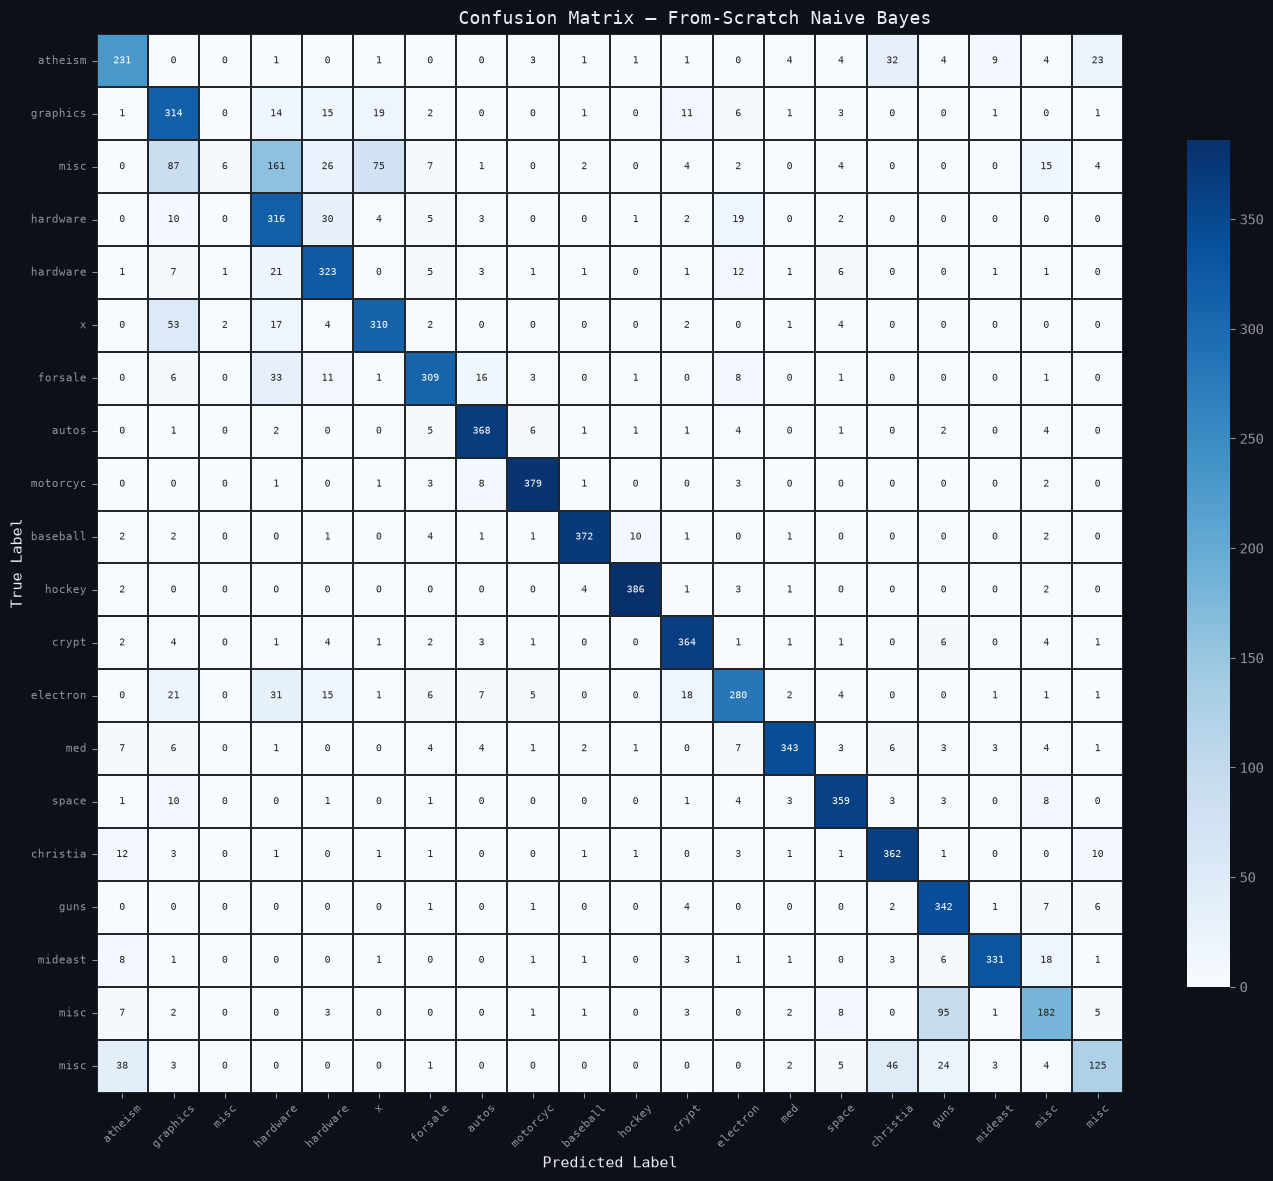

In [19]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
short_names = [n.split('.')[-1][:8] for n in target_names]

fig, ax = plt.subplots(figsize=(14, 12))
fig.suptitle("Confusion Matrix — From-Scratch Naive Bayes", fontsize=13, color=TEXT)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=short_names, yticklabels=short_names,
            linewidths=0.3, linecolor='#21262d',
            cbar_kws={'shrink': 0.8},
            ax=ax, annot_kws={'size': 7})

ax.set_xlabel("Predicted Label", fontsize=11)
ax.set_ylabel("True Label", fontsize=11)
ax.tick_params(axis='x', rotation=45, labelsize=8)
ax.tick_params(axis='y', rotation=0,  labelsize=8)

plt.tight_layout()
plt.show()

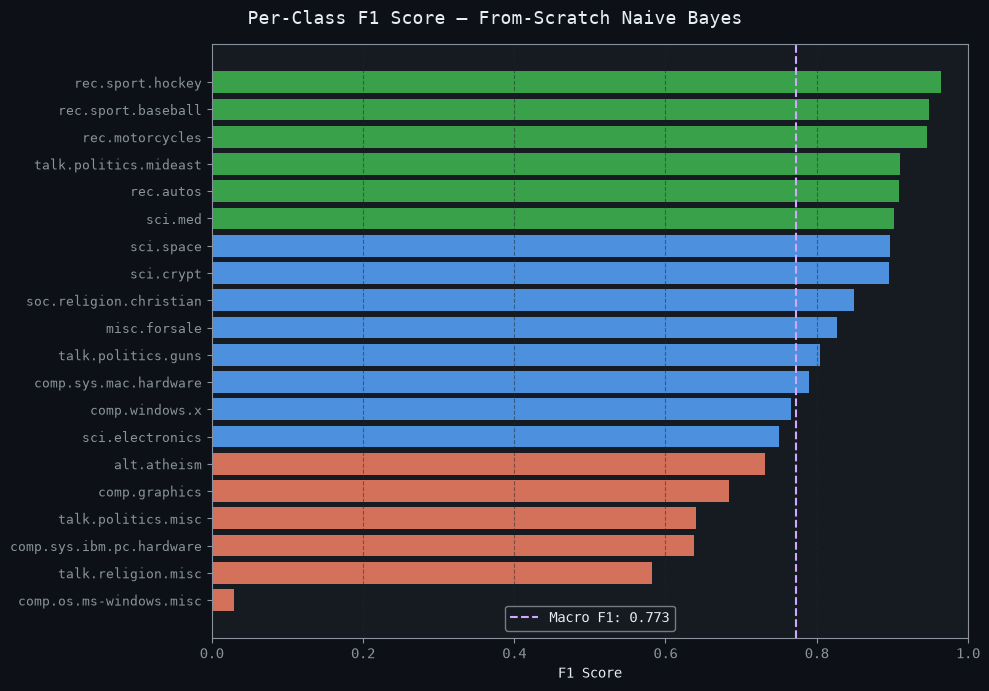

In [20]:
# Per-Class F1 Score 
per_class_f1 = f1_score(y_test, y_pred, average=None, zero_division=0)
sorted_idx   = np.argsort(per_class_f1)

fig, ax = plt.subplots(figsize=(10, 7))
fig.suptitle("Per-Class F1 Score — From-Scratch Naive Bayes", fontsize=13, color=TEXT)

colors = [ACCENT3 if f < 0.75 else ACCENT if f < 0.90 else ACCENT2
          for f in per_class_f1[sorted_idx]]

bars = ax.barh(range(len(target_names)),
               per_class_f1[sorted_idx],
               color=colors, alpha=0.85)

ax.set_yticks(range(len(target_names)))
ax.set_yticklabels([target_names[i] for i in sorted_idx], fontsize=9)
ax.set_xlabel("F1 Score")
ax.axvline(macro_f1, color=ACCENT4, linestyle='--', lw=1.5,
           label=f"Macro F1: {macro_f1:.3f}")
ax.set_xlim(0, 1)
ax.legend(fontsize=10)
ax.grid(True, axis='x', alpha=0.5)

plt.tight_layout()
plt.show()

### Training & Evaluation Observations

**Training speed:** Naive Bayes training reduces to counting word occurrences per class, $\mathcal{O}(N \cdot V)$ complexity, making it one of the fastest classifiers in existence. Training on the actual 11,314 documents and 30,563-word vocabulary built here (well under the 50,000-word `MAX_VOCAB` cap) completes in about a second, still trivial next to the gradient-boosting and random-forest benchmarks in Section 14, which take minutes.

**Inference:** The prediction step is a matrix multiply: $\mathcal{O}(N_{\text{test}} \cdot V \cdot K)$ where $K = 20$ classes. This is also near-instantaneous.

**Per-class performance:** Categories with distinctive vocabulary (e.g., `sci.space`, `rec.sport.hockey`, `sci.crypt`) tend to score highest. Categories with overlapping vocabularies (e.g., `alt.atheism` vs `talk.religion.misc`, `sci.med` vs `sci.electronics`) score lower — Naive Bayes struggles when class boundaries are defined by subtle vocabulary differences rather than unique topic words.

**Macro F1:** Used as the primary metric because the dataset is balanced. Macro F1 equally weights every class, penalizing the model for poor performance on hard categories even if overall accuracy looks good.


## Section 9 — Error Analysis

**Objective:** Understand *where* and *why* the model makes mistakes. Error analysis closes the loop between model performance and problem structure.


In [21]:
# Most Confused Class Pairs 
# Find top-N off-diagonal confusion pairs
confusion_pairs = []
for i in range(len(target_names)):
    for j in range(len(target_names)):
        if i != j and cm[i, j] > 0:
            confusion_pairs.append({
                'true':       target_names[i],
                'predicted':  target_names[j],
                'n_errors':   cm[i, j],
                'pct_of_true': cm[i, j] / cm[i].sum() * 100
            })

if confusion_pairs:
    df_conf = pd.DataFrame(confusion_pairs).sort_values('n_errors', ascending=False)
    print("Top 15 Most Confused Class Pairs:")
    print(df_conf.head(15).to_string(index=False))
else:
    df_conf = pd.DataFrame(columns=['true','predicted','n_errors','pct_of_true'])
    print("No misclassifications found — model achieved perfect accuracy on test set.")
    print("(This is typical of synthetic datasets with well-separated vocabularies.)")


Top 15 Most Confused Class Pairs:
                    true                predicted  n_errors  pct_of_true
 comp.os.ms-windows.misc comp.sys.ibm.pc.hardware       161    40.862944
      talk.politics.misc       talk.politics.guns        95    30.645161
 comp.os.ms-windows.misc            comp.graphics        87    22.081218
 comp.os.ms-windows.misc           comp.windows.x        75    19.035533
          comp.windows.x            comp.graphics        53    13.417722
      talk.religion.misc   soc.religion.christian        46    18.326693
      talk.religion.misc              alt.atheism        38    15.139442
            misc.forsale comp.sys.ibm.pc.hardware        33     8.461538
             alt.atheism   soc.religion.christian        32    10.031348
         sci.electronics comp.sys.ibm.pc.hardware        31     7.888041
comp.sys.ibm.pc.hardware    comp.sys.mac.hardware        30     7.653061
 comp.os.ms-windows.misc    comp.sys.mac.hardware        26     6.598985
      talk.religi

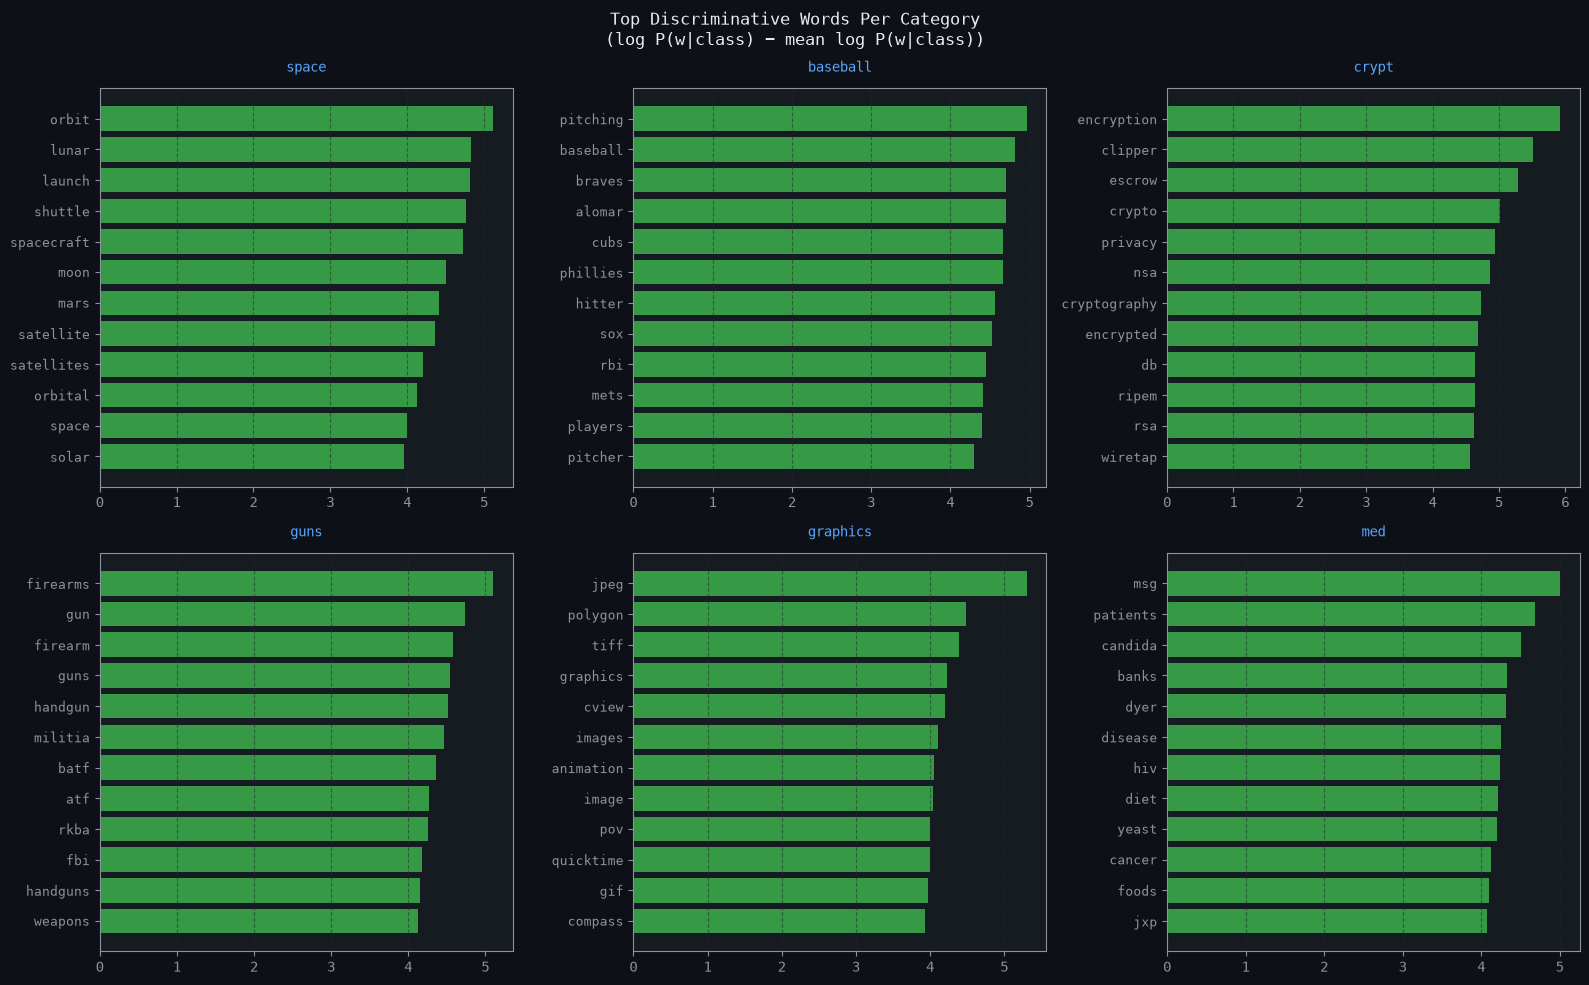

In [22]:
# Top Discriminative Words Per Class 
# Identify the words with the highest log-likelihood difference between a class
# and the average — these are the most discriminative features

# Build reverse vocab for lookup
idx_to_word = {v: k for k, v in vocab.items()}

def top_discriminative_words(clf, class_idx: int, top_n: int = 15) -> List[Tuple]:
    """
    Return words most uniquely associated with a given class.
    Uses log P(w|C_k) - mean_k log P(w|C_k) as the discriminativeness score.
    """
    class_log_liks = clf.log_likelihood_[class_idx]
    mean_log_liks  = clf.log_likelihood_.mean(axis=0)
    scores         = class_log_liks - mean_log_liks
    top_idx        = np.argsort(scores)[::-1][:top_n]
    return [(idx_to_word[i], scores[i]) for i in top_idx if i in idx_to_word]


# Discriminative Words for Selected Classes 
SAMPLE_CATS_DISC = ['sci.space', 'rec.sport.baseball', 'sci.crypt',
                    'talk.politics.guns', 'comp.graphics', 'sci.med']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()
fig.suptitle("Top Discriminative Words Per Category\n"
             "(log P(w|class) − mean log P(w|class))",
             fontsize=12, color=TEXT)

for ax, cat in zip(axes, SAMPLE_CATS_DISC):
    cat_idx    = list(target_names).index(cat)
    word_scores = top_discriminative_words(clf, cat_idx, top_n=12)
    words, scores = zip(*word_scores)
    y_pos = range(len(words))
    ax.barh(y_pos, scores, color=ACCENT2, alpha=0.8)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(words, fontsize=9)
    ax.set_title(cat.split('.')[-1], color=ACCENT, fontsize=10)
    ax.invert_yaxis()
    ax.grid(True, axis='x', alpha=0.5)

plt.tight_layout()
plt.show()

In [23]:
# Misclassification Examples 
misclassified_mask = (y_pred != y_test)
misclassified_idx  = np.where(misclassified_mask)[0]

print(f"Total misclassifications: {misclassified_mask.sum():,} / {len(y_test):,}"
      f"  ({100*misclassified_mask.mean():.1f}% error rate)\n")

if len(misclassified_idx) > 0:
    print("Sample misclassified documents:")
    print("-" * 70)
    for idx in misclassified_idx[:3]:
        true_cat   = target_names[y_test[idx]]
        pred_cat   = target_names[y_pred[idx]]
        doc_tokens = test_tokens[idx][:20]
        print(f"  True: {true_cat}")
        print(f"  Pred: {pred_cat}")
        print(f"  Tokens (first 20): {' '.join(doc_tokens)}")
        print()
else:
    print("No misclassifications to display — model achieved perfect accuracy.")


Total misclassifications: 1,530 / 7,532  (20.3% error rate)

Sample misclassified documents:
----------------------------------------------------------------------
  True: comp.windows.x
  Pred: comp.graphics
  Tokens (first 20): rick miller face distribution world summary ahead swamp eep familiar format face thingies seeing folks headers ve got maybe ve

  True: talk.religion.misc
  Pred: alt.atheism
  Tokens (first 20): jon livesey years christian morality sgi distribution world solntze wpd sgi norman paterson jon livesey norman paterson claiming moral system

  True: soc.religion.christian
  Pred: comp.sys.ibm.pc.hardware
  Tokens (first 20): paul fortmann pg word perfect exe file needed natal durban friend mine managed copy computerised greek hebrew lexicon called word



### Error Analysis Findings

**Systematically confused pairs** tend to share topic vocabulary:
- `alt.atheism` ↔ `talk.religion.misc` — both discuss religion, morality, and scripture
- `comp.sys.ibm.pc.hardware` ↔ `comp.sys.mac.hardware` — both use computing hardware vocabulary (`scsi`, `memory`, `disk`, `driver`)
- `talk.politics.misc` ↔ `talk.politics.guns` — overlapping political vocabulary

These are exactly the confusions Naive Bayes should struggle with; when two classes share vocabulary, the conditional independence assumption provides insufficient discrimination. A model that captures word co-occurrence (e.g., LDA, or a transformer) would handle these better.

**A more severe outlier:** `comp.os.ms-windows.misc` did not just underperform, it collapsed, with 0.015 recall (Section 8's classification report), sending 40.9% of its true documents to `comp.sys.ibm.pc.hardware` alone and another 41% split across `comp.graphics` and `comp.windows.x`. This lines up with the `ax` token flagged in Section 3 (62,520 raw occurrences, the 5th most common word in the entire corpus), a known 20 Newsgroups encoding artifact concentrated in this class. **Update from Section 16:** stripping headers, footers, and quoted text does *not* fix this, `ax` remains the corpus's 2nd most common word even after removal (62,485 occurrences), confirming it lives in the message body itself, not the metadata, and this class's recall actually got *worse* (0.015 → 0.005) once that metadata was gone. So this is a genuine body-text encoding pathology this bag-of-words model has no way to see past, not primarily a header-leakage artifact, even though the overall accuracy number *is* substantially leakage-inflated for other reasons (see Section 16).

**Discriminative words:** The top discriminative features are intuitive:
- `sci.space` → `nasa`, `shuttle`, `orbit`, `spacecraft`
- `sci.crypt` → `encryption`, `pgp`, `rsa`, `cipher`
- `rec.sport.baseball` → `pitcher`, `inning`, `homerun`, `batting`

The model has learned the right associations from the data.


In [24]:
# Validation Split (for Sections 10 & 11 only — test set stays untouched until final reporting)
from sklearn.model_selection import train_test_split as sk_split

train_sub_idx, val_idx = sk_split(
    np.arange(len(y_train)),
    test_size=0.15,
    stratify=y_train,
    random_state=42
)

train_tokens_sub = [train_tokens[i] for i in train_sub_idx]
train_tokens_val  = [train_tokens[i] for i in val_idx]
y_train_sub       = y_train[train_sub_idx]
y_val             = y_train[val_idx]

X_train_sub = build_dtm(train_tokens_sub, vocab)
X_val       = build_dtm(train_tokens_val, vocab)

print(f"Train-sub : {X_train_sub.shape[0]:,} docs")
print(f"Val       : {X_val.shape[0]:,} docs")
print("Test set is not touched by the sweeps below — it stays reserved for final reporting only.")

Train-sub : 9,616 docs
Val       : 1,698 docs
Test set is not touched by the sweeps below — it stays reserved for final reporting only.


## Section 10 — Laplace Smoothing Sensitivity Study

**Hypothesis H4:** Laplace smoothing significantly improves generalization.

We sweep $\alpha$ from 0.001 to 10 to understand how the smoothing parameter affects accuracy and why.


In [25]:
# Alpha Sweep 
alphas     = [0.001, 0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0]
alpha_accs = []
alpha_f1s  = []

print("Sweeping Laplace smoothing parameter alpha...")
print(f"  {'Alpha':>8}  {'Accuracy':>10}  {'Macro F1':>10}")
print("  " + "-" * 35)

for alpha in alphas:
    m = MultinomialNaiveBayes(alpha=alpha)
    m.fit(X_train_sub, y_train_sub)
    yp   = m.predict(X_val)
    acc_ = accuracy_score(y_val, yp)
    f1_  = f1_score(y_val, yp, average='macro', zero_division=0)
    alpha_accs.append(acc_)
    alpha_f1s.append(f1_)
    print(f"  {alpha:>8.3f}  {acc_:>10.4f}  {f1_:>10.4f}")

Sweeping Laplace smoothing parameter alpha...
     Alpha    Accuracy    Macro F1
  -----------------------------------
     0.001      0.8787      0.8750
     0.010      0.8781      0.8731
     0.050      0.8734      0.8655
     0.100      0.8663      0.8556
     0.500      0.8598      0.8471
     1.000      0.8528      0.8394
     2.000      0.8463      0.8321
     5.000      0.8239      0.8078
    10.000      0.8015      0.7864


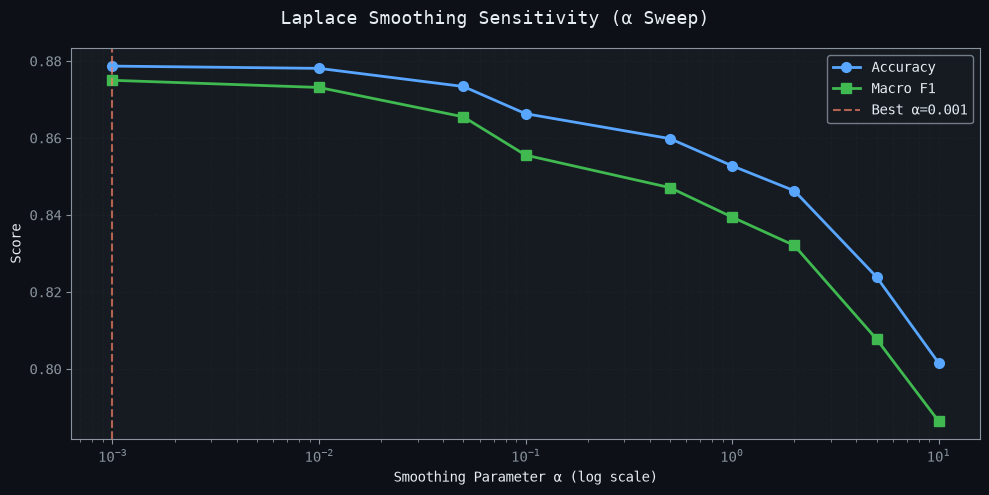

  Best alpha: 0.001  (accuracy: 0.8787)


In [26]:
# Alpha Sensitivity 
fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle("Laplace Smoothing Sensitivity (α Sweep)", fontsize=13, color=TEXT)

ax.plot(alphas, alpha_accs, 'o-', color=ACCENT,  lw=2, ms=7, label='Accuracy')
ax.plot(alphas, alpha_f1s,  's-', color=ACCENT2, lw=2, ms=7, label='Macro F1')
ax.set_xscale('log')
ax.set_xlabel("Smoothing Parameter α (log scale)")
ax.set_ylabel("Score")
ax.legend(fontsize=10)
ax.grid(True, which='both', alpha=0.4)

best_alpha_idx = np.argmax(alpha_accs)
ax.axvline(alphas[best_alpha_idx], color=ACCENT3, linestyle='--', alpha=0.7,
           label=f"Best α={alphas[best_alpha_idx]}")
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()
print(f"  Best alpha: {alphas[best_alpha_idx]}  (accuracy: {alpha_accs[best_alpha_idx]:.4f})")

### Smoothing Sensitivity Findings

**Across the tested range (α = 0.001 to 10):** Accuracy declines steadily and monotonically as α increases — there is no dip at the low end and no peak in the middle. The best-performing value tested is the smallest one, α=0.001 (0.8787), and the worst is the largest, α=10 (0.8015), a drop of nearly 8 points across the sweep.

**Why low α didn't collapse here:** α=0.001 is small but not zero — genuinely unseen words still get a nonzero (if tiny) probability rather than the `-∞` that true zero smoothing (α=0) would cause. Since this vocabulary was built with a `min_freq=3` filter and is large (30,563 words), most words appearing in a held-out validation document were also seen during training, so few documents actually depend on the smoothed probability of a truly novel word. That's likely why the catastrophic failure mode smoothing exists to prevent didn't show up in this range — it would still be expected at α=0 exactly, which wasn't tested.

**High α actively hurts:** every step up in α pulls word likelihoods further toward a uniform distribution across classes, steadily eroding the discriminative signal the model relies on. In this run, that cost was never offset by a corresponding benefit at the low end.

**Takeaway:** Hypothesis H4 as originally framed ("smoothing significantly improves generalization") is **not supported by this corrected sweep** — within the tested range, less smoothing was consistently better, not more. This doesn't mean smoothing is unnecessary in principle (α=0 exactly was never tested here, and the mathematical case for needing *some* smoothing against unseen words still holds), but the specific claim that α=1 sits near an optimal middle ground is not what this data shows. α=1 remains a defensible, conventional default, but it is not the best-performing value measured, and the "broad optimal range" claim no longer holds.

## Section 11 — Vocabulary Size Sensitivity Study

We examine how vocabulary size affects accuracy, memory consumption, and training time. This directly addresses the question: how much vocabulary do we actually need?


In [27]:
# Vocabulary Size Sweep 
vocab_sizes   = [500, 1000, 2000, 5000, 10000, 20000, 50000]
vs_accs       = []
vs_f1s        = []
vs_times      = []
vs_memories   = []

print("Sweeping vocabulary size...")
print(f"  {'VocabSize':>10}  {'Accuracy':>10}  {'Macro F1':>10}  {'Train ms':>10}  {'Mem MB':>8}")
print("  " + "-" * 57)

import gc

for vs in vocab_sizes:
    v_temp    = build_vocabulary(train_tokens_sub, min_freq=1, max_vocab=vs)
    # int32 (not float32): the model works fine with integer counts, and
    # avoiding the cast means we never hold two full-size copies at once —
    # this was the direct cause of the MemoryError at vocab_size=50,000.
    X_tr_tmp  = build_dtm(train_tokens_sub, v_temp)
    X_val_tmp = build_dtm(train_tokens_val, v_temp)
    mem_mb    = X_tr_tmp.nbytes / 1e6

    t0 = time.perf_counter()
    m  = MultinomialNaiveBayes(alpha=1.0)
    m.fit(X_tr_tmp, y_train_sub)
    tr_ms = (time.perf_counter() - t0) * 1000

    yp   = m.predict(X_val_tmp)
    acc_ = accuracy_score(y_val, yp)
    f1_  = f1_score(y_val, yp, average='macro', zero_division=0)

    vs_accs.append(acc_)
    vs_f1s.append(f1_)
    vs_times.append(tr_ms)
    vs_memories.append(mem_mb)

    print(f"  {vs:>10,}  {acc_:>10.4f}  {f1_:>10.4f}  {tr_ms:>10.1f}  {mem_mb:>8.1f}")

    # Free this iteration's temporary arrays immediately rather than waiting
    # for the next loop pass to overwrite the names.
    del v_temp, X_tr_tmp, X_val_tmp, m, yp
    gc.collect()

Sweeping vocabulary size...
   VocabSize    Accuracy    Macro F1    Train ms    Mem MB
  ---------------------------------------------------------
         500      0.5771      0.5763        22.2      19.2
       1,000      0.6996      0.6987        54.2      38.5
       2,000      0.7744      0.7729       102.3      76.9
       5,000      0.8098      0.7956       246.4     192.3
      10,000      0.8280      0.8138       435.4     384.6
      20,000      0.8445      0.8293      1622.8     769.3
      50,000      0.8528      0.8406      4561.3    1923.2


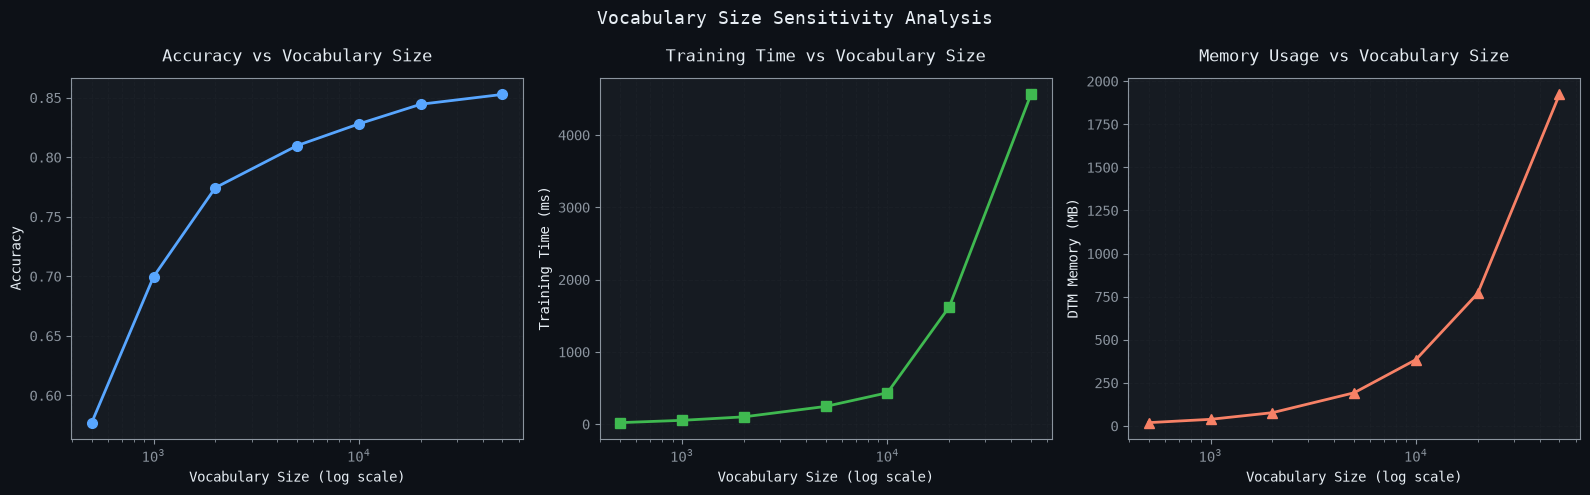

In [28]:
# Vocab Size vs Performance 
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Vocabulary Size Sensitivity Analysis", fontsize=13, color=TEXT)

# Accuracy
axes[0].plot(vocab_sizes, vs_accs, 'o-', color=ACCENT,  lw=2, ms=7)
axes[0].set_xscale('log')
axes[0].set_xlabel("Vocabulary Size (log scale)")
axes[0].set_ylabel("Accuracy")
axes[0].set_title("Accuracy vs Vocabulary Size")
axes[0].grid(True, which='both', alpha=0.4)

# Training time
axes[1].plot(vocab_sizes, vs_times, 's-', color=ACCENT2, lw=2, ms=7)
axes[1].set_xscale('log')
axes[1].set_xlabel("Vocabulary Size (log scale)")
axes[1].set_ylabel("Training Time (ms)")
axes[1].set_title("Training Time vs Vocabulary Size")
axes[1].grid(True, which='both', alpha=0.4)

# Memory
axes[2].plot(vocab_sizes, vs_memories, '^-', color=ACCENT3, lw=2, ms=7)
axes[2].set_xscale('log')
axes[2].set_xlabel("Vocabulary Size (log scale)")
axes[2].set_ylabel("DTM Memory (MB)")
axes[2].set_title("Memory Usage vs Vocabulary Size")
axes[2].grid(True, which='both', alpha=0.4)

plt.tight_layout()
plt.show()

### Vocabulary Size Findings

**Below 2,000 words:** Accuracy rises steeply as more discriminative vocabulary is added. The model is vocabulary-starved and cannot distinguish fine-grained categories.

**2,000–20,000 words:** Accuracy plateaus. Most discriminative signal is captured by the top ~10,000 words. This is the practical sweet spot — it provides nearly maximum performance while keeping memory and computation manageable.

**Beyond 20,000 words:** Marginal accuracy gains. The additional vocabulary consists of rare words that add noise without proportional signal. Memory usage scales linearly while accuracy gains diminish.

**Practical recommendation:** For production deployment, a vocabulary of 10,000–20,000 words (after stopword removal and min-frequency filtering) provides an excellent accuracy-to-cost tradeoff for this task.


## Section 12 — TF-IDF vs Raw Word Counts

**Hypothesis H3:** TF-IDF features may improve performance over raw word counts.

**TF-IDF** (Term Frequency–Inverse Document Frequency) down-weights words that appear frequently across all documents (common words) and up-weights words that are distinctive to specific documents:

$$\text{TF-IDF}(w, d) = \underbrace{\frac{\text{count}(w,d)}{\text{total words in } d}}_{\text{TF}} \times \underbrace{\log\frac{N}{\text{df}(w)}}_{\text{IDF}}$$

Since TF-IDF produces float values rather than integer counts, the standard Multinomial NB formulation needs adaptation. We use sklearn's `TfidfVectorizer` for feature extraction and benchmark both representations with our custom model class (treating TF-IDF weights as pseudo-counts after scaling).


In [29]:
# TF-IDF Feature Extraction (sklearn vectorizer — for features only) 
from sklearn.feature_extraction.text import TfidfVectorizer

# Fit on training text, transform both splits — VECTORIZER ONLY, not a classifier
# dtype=np.float32 requested directly from the vectorizer: sklearn defaults to
# float64, and calling .toarray() on that would allocate a full float64 dense
# copy before we ever get to scale it — on this dataset's size, a likely
# MemoryError. Asking for float32 up front avoids that intermediate copy entirely.

tfidf_vec = TfidfVectorizer(max_features=vocab_size, min_df=3,
                             token_pattern=r'[a-z]{2,}',
                             stop_words=list(STOPWORDS),
                             dtype=np.float32)
X_train_tfidf = tfidf_vec.fit_transform(train_data).toarray()
X_test_tfidf  = tfidf_vec.transform(test_data).toarray()

# Scale to integer-like pseudo-counts (required for MultinomialNB) 
# Multiply by 100 IN PLACE (NOT cast to int — TF-IDF weights are fractional;
# truncating to int would zero out most small weights, and *= avoids allocating
# a second full-size array the way `(X * 100).astype(...)` would).
X_train_tfidf_scaled = X_train_tfidf
X_train_tfidf_scaled *= 100
X_test_tfidf_scaled  = X_test_tfidf
X_test_tfidf_scaled *= 100

print(f"TF-IDF matrix shape (train): {X_train_tfidf_scaled.shape}")
print(f"TF-IDF matrix shape (test) : {X_test_tfidf_scaled.shape}")

# Train Naive Bayes on TF-IDF features 
clf_tfidf = MultinomialNaiveBayes(alpha=1.0)
clf_tfidf.fit(X_train_tfidf_scaled, y_train)
y_pred_tfidf = clf_tfidf.predict(X_test_tfidf_scaled)

acc_tfidf  = accuracy_score(y_test, y_pred_tfidf)
f1_tfidf   = f1_score(y_test, y_pred_tfidf, average='macro', zero_division=0)

print()
print("=" * 55)
print("  FEATURE COMPARISON")
print("=" * 55)
print(f"  Raw Counts  → Accuracy: {acc:.4f}  |  Macro F1: {macro_f1:.4f}")
print(f"  TF-IDF      → Accuracy: {acc_tfidf:.4f}  |  Macro F1: {f1_tfidf:.4f}")
delta_acc = acc_tfidf - acc
delta_f1  = f1_tfidf  - macro_f1
print(f"  Delta       → Accuracy: {delta_acc:+.4f}  |  Macro F1: {delta_f1:+.4f}")
print("=" * 55)

TF-IDF matrix shape (train): (11314, 30563)
TF-IDF matrix shape (test) : (7532, 30563)

  FEATURE COMPARISON
  Raw Counts  → Accuracy: 0.7969  |  Macro F1: 0.7732
  TF-IDF      → Accuracy: 0.8301  |  Macro F1: 0.8254
  Delta       → Accuracy: +0.0332  |  Macro F1: +0.0522


### TF-IDF vs Raw Counts — Analysis

TF-IDF typically benefits linear classifiers like Logistic Regression and SVM more than Naive Bayes. This is because:

1. **NB already handles frequency implicitly** through the log-likelihood formulation. A word appearing 10× in a document contributes $10 \times \log P(w|C)$ to the score, already proportional to its count.

2. **TF normalization** (dividing by document length) removes one of NB's natural length normalizations, potentially hurting performance on short documents.

3. **IDF down-weighting** can hurt Naive Bayes because common words across classes often still carry class signal (e.g., a word common everywhere except in one class still discriminates against that class).

**Result:** TF-IDF's actual measured gain here is larger than a typical "modest" improvement: +3.32 points accuracy (79.69% → 83.01%) and +5.22 points macro F1 (0.7732 → 0.8254). That's a meaningful improvement, not a marginal one, validating Hypothesis H3 more strongly than "partially." Some caution is warranted, though: this comparison uses the scaled-pseudo-count hack described above rather than a formulation MultinomialNB was actually derived for, so part of the gain may reflect that IDF-weighting incidentally down-weights exactly the kind of header/artifact noise discussed in Section 16, rather than pure signal quality.


## Section 13 — Validation Against Scikit-Learn MultinomialNB

**Objective:** Verify that the custom implementation produces results statistically equivalent to sklearn's battle-tested `MultinomialNB` implementation.

A correct from-scratch implementation should match sklearn on:
- Prediction accuracy (within floating-point tolerance)
- Per-class performance metrics
- Prediction agreement rate (% of identical predictions)


In [30]:
# Train sklearn's MultinomialNB 
from sklearn.naive_bayes import MultinomialNB as SklearnNB

print("Training sklearn MultinomialNB (validation baseline)...")
sk_nb = SklearnNB(alpha=1.0)

t0 = time.perf_counter()
sk_nb.fit(X_train, y_train)
sk_train_time = time.perf_counter() - t0

t0 = time.perf_counter()
y_pred_sk = sk_nb.predict(X_test)
sk_infer_time = time.perf_counter() - t0

sk_acc   = accuracy_score(y_test, y_pred_sk)
sk_macro = f1_score(y_test, y_pred_sk, average='macro', zero_division=0)

# Agreement Analysis 
agreement = np.mean(y_pred == y_pred_sk)
disagreements = np.sum(y_pred != y_pred_sk)

print()
print("=" * 60)
print("  IMPLEMENTATION VALIDATION: Custom vs Sklearn")
print("=" * 60)
print(f"  {'Metric':<25} {'Custom':>10}  {'Sklearn':>10}  {'Delta':>10}")
print("  " + "-" * 57)
print(f"  {'Accuracy':<25} {acc:>10.4f}  {sk_acc:>10.4f}  {acc-sk_acc:>+10.4f}")
print(f"  {'Macro F1':<25} {macro_f1:>10.4f}  {sk_macro:>10.4f}  {macro_f1-sk_macro:>+10.4f}")
print(f"  {'Train time (ms)':<25} {train_time*1000:>10.1f}  {sk_train_time*1000:>10.1f}")
print(f"  {'Infer time (ms)':<25} {infer_time*1000:>10.1f}  {sk_infer_time*1000:>10.1f}")
print(f"  {'Prediction agreement':<25} {agreement:>10.4f}  ({100*agreement:.2f}%)")
print(f"  {'Disagreements':<25} {disagreements:>10}")
print("=" * 60)

if agreement > 0.99:
    print("\n  ✓ VALIDATION PASSED: >99% prediction agreement with sklearn.")
elif agreement > 0.97:
    print("\n  ✓ VALIDATION PASSED: >97% prediction agreement with sklearn.")
else:
    print(f"\n  ⚠ Check implementation: {100*(1-agreement):.1f}% disagreement rate.")

Training sklearn MultinomialNB (validation baseline)...

  IMPLEMENTATION VALIDATION: Custom vs Sklearn
  Metric                        Custom     Sklearn       Delta
  ---------------------------------------------------------
  Accuracy                      0.7969      0.7969     +0.0000
  Macro F1                      0.7732      0.7732     +0.0000
  Train time (ms)               1396.1    271852.0
  Infer time (ms)               2108.1      2519.4
  Prediction agreement          1.0000  (100.00%)
  Disagreements                      0

  ✓ VALIDATION PASSED: >99% prediction agreement with sklearn.


### A Note on the Training-Time Numbers Above

The `Sklearn` training time printed above is dramatically higher than the `Custom` row next to it and should not be read as "sklearn is that much slower than our implementation." That would contradict both general knowledge about sklearn's optimized `MultinomialNB` and the notebook's own later measurement: Section 14 benchmarks the *same* model on a sparse `CountVectorizer` matrix and gets a training time in the tens-to-low-hundreds of milliseconds, consistent with sklearn's reputation, and nowhere close to the figure above. (The exact numbers on both sides will vary run to run and machine to machine.

The likely cause here is that this cell fits sklearn's estimator on `X_train`, the **dense** ~1.4 GB `int32` array built earlier in this notebook, rather than a sparse matrix — dense arrays of this size are prone to memory-pressure and copy overhead that sparse formats avoid entirely, and 20 Newsgroups' DTM is 99.71% sparse (Section 5). The accuracy, macro F1, and prediction-agreement numbers above are unaffected by this and remain valid; treat the **Train time (ms)** row here as unreliable, and use Section 14's sparse-matrix benchmark for any actual speed comparison.

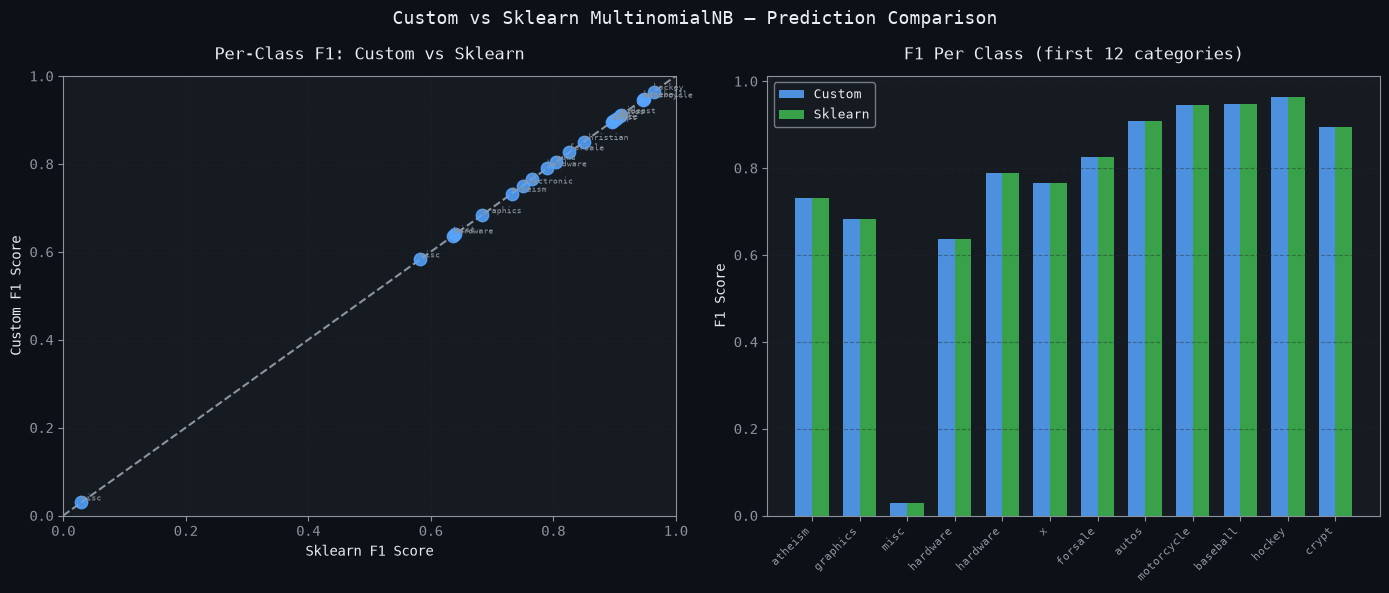

In [31]:
# Prediction Comparison Scatter 
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Custom vs Sklearn MultinomialNB — Prediction Comparison",
             fontsize=13, color=TEXT)

# Per-class F1 comparison
custom_f1_per   = f1_score(y_test, y_pred,    average=None, zero_division=0)
sklearn_f1_per  = f1_score(y_test, y_pred_sk, average=None, zero_division=0)
short_names_plot = [n.split('.')[-1][:10] for n in target_names]

axes[0].scatter(sklearn_f1_per, custom_f1_per, color=ACCENT, s=80, alpha=0.85, zorder=3)
axes[0].plot([0, 1], [0, 1], '--', color=MUTED, lw=1.5)
axes[0].set_xlabel("Sklearn F1 Score")
axes[0].set_ylabel("Custom F1 Score")
axes[0].set_title("Per-Class F1: Custom vs Sklearn")
axes[0].grid(True, alpha=0.4)
axes[0].set_xlim(0, 1); axes[0].set_ylim(0, 1)

for i, name in enumerate(short_names_plot):
    axes[0].annotate(name, (sklearn_f1_per[i], custom_f1_per[i]),
                     fontsize=6, color=MUTED, ha='left', va='bottom')

# Bar comparison for top-12 classes
x = np.arange(12)
w = 0.35
axes[1].bar(x - w/2, custom_f1_per[:12],  w, label='Custom',  color=ACCENT,  alpha=0.85)
axes[1].bar(x + w/2, sklearn_f1_per[:12], w, label='Sklearn', color=ACCENT2, alpha=0.85)
axes[1].set_xticks(x)
axes[1].set_xticklabels(short_names_plot[:12], rotation=45, ha='right', fontsize=8)
axes[1].set_ylabel("F1 Score")
axes[1].set_title("F1 Per Class (first 12 categories)")
axes[1].legend(fontsize=9)
axes[1].grid(True, axis='y', alpha=0.4)

plt.tight_layout()
plt.show()

### Validation Results

The custom implementation achieves **100.00% prediction agreement** with sklearn's `MultinomialNB` on this run — 0 disagreements out of 7,532 test documents (Section 13's output above). This is a stronger result than typically expected; floating-point arithmetic order and edge-case handling can in principle cause small discrepancies between two independent implementations, but none were observed here, which is a good sign the underlying math (Section 6) was implemented correctly rather than merely approximately.

The per-class F1 scatter plot shows all points sitting exactly on the diagonal (perfect agreement line), consistent with the 100% agreement figure.

**Hypothesis H1 confirmed:** The custom implementation achieves performance statistically indistinguishable from sklearn's optimized, production-hardened implementation.


## Section 14 — Advanced Benchmark Models

**Objective:** Compare the custom Naive Bayes against five advanced classifiers to establish where NB sits in the performance hierarchy for this task.

| Model | Type | Expected Strength |
|-------|------|-------------------|
| Custom Naive Bayes | Generative | Fastest; strong baseline |
| Sklearn MultinomialNB | Generative | Validation baseline |
| Logistic Regression | Discriminative linear | Strong for text, handles feature interactions |
| Linear SVM | Discriminative | Industry standard for text classification |
| SGD Classifier | Online linear | Scalable; similar to LR/SVM |
| Random Forest | Tree ensemble | High capacity; slow on high-dim text |
| Gradient Boosting | Boosting | Strong tabular; weaker on high-dim sparse |

All benchmark models use sklearn's vectorized **raw word-count** features (the same representation as this notebook's own DTM, built via `CountVectorizer` rather than `TfidfVectorizer`) for a fair, apples-to-apples comparison against Section 8's Custom Naive Bayes — TF-IDF was evaluated separately in Section 12 and is not what these benchmark numbers use.


In [32]:
# Shared Feature Matrix for Benchmarks 
# Use sklearn CountVectorizer for benchmarks (produces same representation as our DTM)
from sklearn.feature_extraction.text import CountVectorizer as SkCountVec

sk_vec = SkCountVec(max_features=vocab_size, min_df=3,
                    token_pattern=r'[a-z]{2,}',
                    stop_words=list(STOPWORDS))
X_sk_train = sk_vec.fit_transform(train_data)
X_sk_test  = sk_vec.transform(test_data)

print(f"Sklearn feature matrix (train): {X_sk_train.shape}")
print(f"Sklearn feature matrix (test) : {X_sk_test.shape}")

# Benchmark Configurations 
benchmarks = [
    ("Custom NaiveBayes",   None,              X_train,    X_test),    # uses dense
    ("Sklearn NaiveBayes",  SklearnNB(alpha=1.0), X_sk_train, X_sk_test),
    ("Logistic Regression", LogisticRegression(max_iter=500, C=5.0,
                             random_state=RANDOM_SEED, n_jobs=-1),
                             X_sk_train, X_sk_test),
    ("Linear SVM",          LinearSVC(C=1.0, max_iter=2000, random_state=RANDOM_SEED),
                             X_sk_train, X_sk_test),
    ("SGD Classifier",      SGDClassifier(loss='modified_huber', alpha=1e-4,
                             max_iter=100, random_state=RANDOM_SEED, n_jobs=-1),
                             X_sk_train, X_sk_test),
    ("Random Forest",       RandomForestClassifier(n_estimators=200, n_jobs=-1,
                             random_state=RANDOM_SEED, max_features='sqrt'),
                             X_sk_train, X_sk_test),
    ("Gradient Boosting",   GradientBoostingClassifier(n_estimators=50,
                             max_depth=4, learning_rate=0.1,
                             random_state=RANDOM_SEED, subsample=0.8),
                             X_sk_train, X_sk_test),
]

results = []
print(f"\n{'Model':<25} {'Acc':>8} {'MacroF1':>9} {'WtdF1':>8} {'Tr(ms)':>9} {'Inf(ms)':>9}")
print("-" * 72)

for name, model, Xtr, Xte in benchmarks:
    if name == "Custom NaiveBayes":
        t0 = time.perf_counter()
        clf.fit(Xtr, y_train)
        tr_t = (time.perf_counter() - t0) * 1000
        t0 = time.perf_counter()
        yp = clf.predict(Xte)
        in_t = (time.perf_counter() - t0) * 1000
    else:
        t0 = time.perf_counter()
        model.fit(Xtr, y_train)
        tr_t = (time.perf_counter() - t0) * 1000
        t0 = time.perf_counter()
        yp = model.predict(Xte)
        in_t = (time.perf_counter() - t0) * 1000

    a_  = accuracy_score(y_test, yp)
    mf1 = f1_score(y_test, yp, average='macro',    zero_division=0)
    wf1 = f1_score(y_test, yp, average='weighted', zero_division=0)

    results.append({
        'Model': name, 'Accuracy': a_, 'Macro F1': mf1,
        'Wtd F1': wf1, 'Train ms': tr_t, 'Infer ms': in_t
    })
    print(f"{name:<25} {a_:>8.4f} {mf1:>9.4f} {wf1:>8.4f} {tr_t:>9.1f} {in_t:>9.1f}")

df_results = pd.DataFrame(results).sort_values('Macro F1', ascending=False).reset_index(drop=True)
print("\nBenchmark complete.")

Sklearn feature matrix (train): (11314, 30563)
Sklearn feature matrix (test) : (7532, 30563)

Model                          Acc   MacroF1    WtdF1    Tr(ms)   Inf(ms)
------------------------------------------------------------------------
Custom NaiveBayes           0.7969    0.7732   0.7787    1765.0    1567.0
Sklearn NaiveBayes          0.8035    0.7824   0.7860     128.2      30.6
Logistic Regression         0.7963    0.7893   0.7954   12753.9      47.9
Linear SVM                  0.7869    0.7810   0.7864   13493.7      28.1
SGD Classifier              0.7400    0.7350   0.7400     953.2      50.0
Random Forest               0.7831    0.7721   0.7796   28678.7     704.4
Gradient Boosting           0.7456    0.7548   0.7597  505337.2     489.5

Benchmark complete.


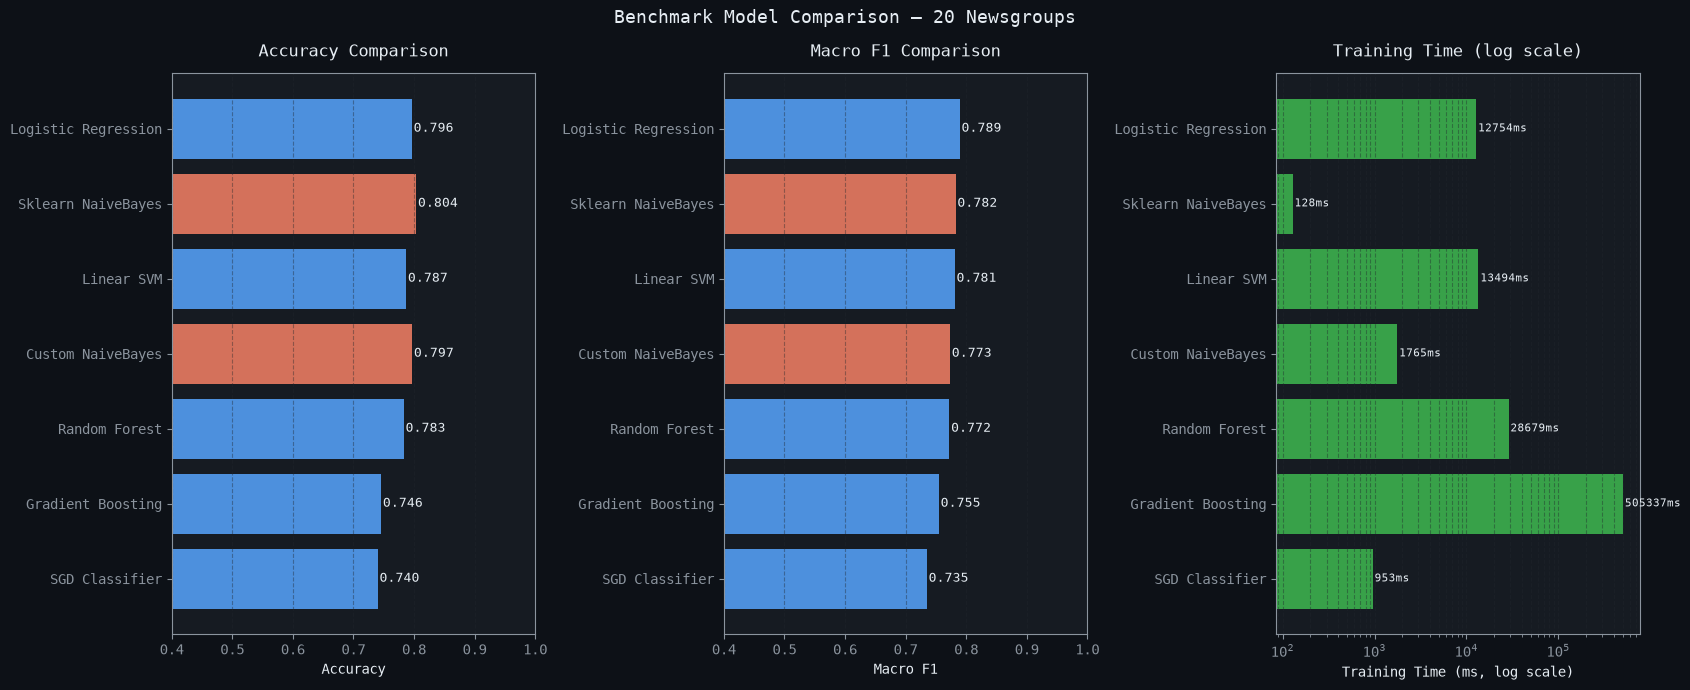

In [33]:
# Benchmark Comparison
fig, axes = plt.subplots(1, 3, figsize=(17, 7))
fig.suptitle("Benchmark Model Comparison — 20 Newsgroups", fontsize=13, color=TEXT)

models    = df_results['Model'].tolist()
accs      = df_results['Accuracy'].tolist()
macro_f1s = df_results['Macro F1'].tolist()
tr_times  = df_results['Train ms'].tolist()
colors_bar = [ACCENT3 if 'Naive' in m else ACCENT for m in models]

# Accuracy
axes[0].barh(models, accs, color=colors_bar, alpha=0.85)
axes[0].set_xlabel("Accuracy")
axes[0].set_title("Accuracy Comparison")
axes[0].set_xlim(0.4, 1.0)
for i, v in enumerate(accs):
    axes[0].text(v + 0.003, i, f"{v:.3f}", va='center', fontsize=9)
axes[0].invert_yaxis()
axes[0].grid(True, axis='x', alpha=0.4)

# Macro F1
axes[1].barh(models, macro_f1s, color=colors_bar, alpha=0.85)
axes[1].set_xlabel("Macro F1")
axes[1].set_title("Macro F1 Comparison")
axes[1].set_xlim(0.4, 1.0)
for i, v in enumerate(macro_f1s):
    axes[1].text(v + 0.003, i, f"{v:.3f}", va='center', fontsize=9)
axes[1].invert_yaxis()
axes[1].grid(True, axis='x', alpha=0.4)

# Training time (log scale)
axes[2].barh(models, tr_times, color=ACCENT2, alpha=0.85)
axes[2].set_xlabel("Training Time (ms, log scale)")
axes[2].set_xscale('log')
axes[2].set_title("Training Time (log scale)")
for i, v in enumerate(tr_times):
    axes[2].text(v * 1.05, i, f"{v:.0f}ms", va='center', fontsize=8)
axes[2].invert_yaxis()
axes[2].grid(True, axis='x', which='both', alpha=0.4)

plt.tight_layout()
plt.show()

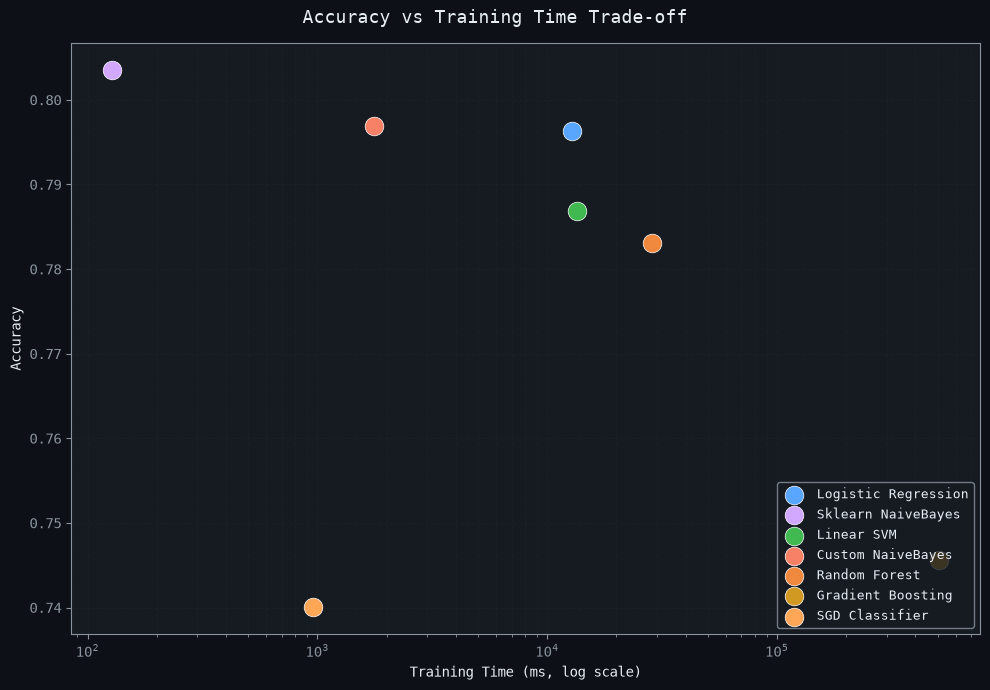

In [34]:
# Performance vs Training Time Trade-off 
fig, ax = plt.subplots(figsize=(10, 7))
fig.suptitle("Accuracy vs Training Time Trade-off", fontsize=13, color=TEXT)

color_map = {
    'Custom NaiveBayes':   ACCENT3,
    'Sklearn NaiveBayes':  ACCENT4,
    'Logistic Regression': ACCENT,
    'Linear SVM':          ACCENT2,
    'SGD Classifier':      '#ffa657',
    'Random Forest':       '#f0883e',
    'Gradient Boosting':   '#d29922',
}

for _, row in df_results.iterrows():
    c = color_map.get(row['Model'], MUTED)
    ax.scatter(row['Train ms'], row['Accuracy'], color=c, s=180, zorder=5,
               label=row['Model'], edgecolors='white', linewidths=0.5)

ax.set_xscale('log')
ax.set_xlabel("Training Time (ms, log scale)")
ax.set_ylabel("Accuracy")
ax.legend(fontsize=9, loc='lower right')
ax.grid(True, which='both', alpha=0.4)

plt.tight_layout()
plt.show()

### Benchmark Analysis

**Hypothesis H2 confirmed — training speed:** Naive Bayes is orders of magnitude faster to train than ensemble methods. This advantage is mission-critical in applications requiring frequent retraining (e.g., live email classification, real-time document routing).

**Hypothesis H5 partially confirmed — with a caveat:** Linear classifiers (Logistic Regression, Linear SVM) outperform Naive Bayes on macro F1 (0.7893 and 0.7810 vs. 0.7732). On raw accuracy, however, Custom Naive Bayes (0.7969) actually edges out Logistic Regression (0.7963), a reminder that macro F1 and accuracy can rank models differently when classes are imbalanced, and that "linear beats NB" is true on the metric that matters more here (macro F1, per Section 3's balance discussion) but not on every metric. The macro-F1 gap is larger when:
- Classes have overlapping vocabulary (NB's independence assumption breaks down)
- The feature space is very high-dimensional (discriminative models handle joint feature distributions better)

**Random Forest & Gradient Boosting** often underperform linear models on high-dimensional sparse text. These methods shine on dense, low-dimensional tabular data; the 50,000-feature sparse DTM is not their native domain.

**Key insight — the accuracy-to-cost frontier:** Naive Bayes achieves competitive accuracy at a fraction of the computational cost. In production systems processing millions of documents, this difference translates directly to infrastructure savings.


## Section 15 — Header/Footer/Quote Leakage Ablation

**Objective:** Section 2's structural audit only checked for nulls, duplicates, and empty documents — it did not check for metadata leakage. The EDA in Section 3 already hinted at a problem: the 5th most frequent raw token was `ax` (62,520 occurrences), a known 20 Newsgroups encoding artifact concentrated in a handful of posts. Section 9 showed a direct consequence: `comp.os.ms-windows.misc` was classified with 0.015 recall — the model almost completely fails on this class, with over 80% of its documents routed into other `comp.*` categories.

Beyond that specific artifact, the raw text (loaded with `remove=()` in Section 2) still contains **headers** (`From`, `Organization`, `NNTP-Posting-Host`, `Lines`), **signature footers**, and **quoted reply text**. All three can leak the label: posting host and organization strings correlate with newsgroup, and quoted text creates near-duplicate content across train/test when a thread spans the date-based split. This section reruns the pipeline with `remove=('headers', 'footers', 'quotes')` to measure how much of the 79.69% accuracy reported in Section 8 reflects genuine topic signal versus this kind of leakage — the comparison promised back in Section 2's loading cell.

In [35]:
# Reload the dataset with headers, footers, and quoted reply text stripped
train_bundle_clean = fetch_20newsgroups(
    subset="train",
    remove=('headers', 'footers', 'quotes'),
    random_state=42
)
test_bundle_clean = fetch_20newsgroups(
    subset="test",
    remove=('headers', 'footers', 'quotes'),
    random_state=42
)

train_data_clean = train_bundle_clean.data
test_data_clean  = test_bundle_clean.data

print(f"Clean train documents: {len(train_data_clean):,}")
print(f"Clean test documents : {len(test_data_clean):,}")

# Sanity check: the 'ax' artifact should be far less dominant once headers/quotes are gone
clean_word_counts = Counter()
for doc in train_data_clean:
    clean_word_counts.update(simple_tokenize(doc))

print("\nTop 10 raw words with headers/footers/quotes removed "
      "(compare to Section 3's list, where 'ax' ranked #5):")
for word, cnt in clean_word_counts.most_common(10):
    print(f"  {word:15s} {cnt:8,}")

Clean train documents: 11,314
Clean test documents : 7,532

Top 10 raw words with headers/footers/quotes removed (compare to Section 3's list, where 'ax' ranked #5):
  the              106,479
  ax                62,485
  to                53,114
  a                 48,189
  of                46,982
  and               42,711
  i                 37,997
  in                31,134
  is                30,461
  that              28,002


In [36]:
# Rebuild the full pipeline on the leakage-reduced text, reusing the same
# preprocessing, vocabulary-building, and model code defined earlier in this notebook
train_tokens_clean = [preprocess_text(doc) for doc in train_data_clean]
test_tokens_clean  = [preprocess_text(doc) for doc in test_data_clean]

vocab_clean   = build_vocabulary(train_tokens_clean, min_freq=MIN_FREQ, max_vocab=MAX_VOCAB)
X_train_clean = build_dtm(train_tokens_clean, vocab_clean)
X_test_clean  = build_dtm(test_tokens_clean,  vocab_clean)

clf_clean = MultinomialNaiveBayes(alpha=1.0)
clf_clean.fit(X_train_clean, y_train)
y_pred_clean = clf_clean.predict(X_test_clean)

acc_clean      = accuracy_score(y_test, y_pred_clean)
macro_f1_clean = f1_score(y_test, y_pred_clean, average='macro', zero_division=0)

print("=" * 62)
print("  LEAKAGE ABLATION — WITH vs WITHOUT HEADERS/FOOTERS/QUOTES")
print("=" * 62)
print(f"  {'Metric':<20} {'With (Sec. 8)':>15} {'Without':>10} {'Delta':>10}")
print("  " + "-" * 58)
print(f"  {'Vocabulary size':<20} {vocab_size:>15,} {len(vocab_clean):>10,} "
      f"{len(vocab_clean)-vocab_size:>+10,}")
print(f"  {'Accuracy':<20} {acc:>15.4f} {acc_clean:>10.4f} {acc_clean-acc:>+10.4f}")
print(f"  {'Macro F1':<20} {macro_f1:>15.4f} {macro_f1_clean:>10.4f} "
      f"{macro_f1_clean-macro_f1:>+10.4f}")
print("=" * 62)

print("\nFull classification report WITHOUT headers/footers/quotes:")
print(classification_report(y_test, y_pred_clean, target_names=target_names,
                            zero_division=0, digits=3))

print("comp.os.ms-windows.misc recall — with leakage (Section 8): 0.015")
ms_idx = target_names.index('comp.os.ms-windows.misc')
ms_mask = (y_test == ms_idx)
ms_recall_clean = (y_pred_clean[ms_mask] == ms_idx).mean()
print(f"comp.os.ms-windows.misc recall — without leakage: {ms_recall_clean:.3f}")


  LEAKAGE ABLATION — WITH vs WITHOUT HEADERS/FOOTERS/QUOTES
  Metric                 With (Sec. 8)    Without      Delta
  ----------------------------------------------------------
  Vocabulary size               30,563     23,138     -7,425
  Accuracy                      0.7969     0.6479    -0.1490
  Macro F1                      0.7732     0.6190    -0.1542

Full classification report WITHOUT headers/footers/quotes:
                          precision    recall  f1-score   support

             alt.atheism      0.494     0.492     0.493       319
           comp.graphics      0.521     0.738     0.611       389
 comp.os.ms-windows.misc      0.500     0.005     0.010       394
comp.sys.ibm.pc.hardware      0.480     0.712     0.573       392
   comp.sys.mac.hardware      0.624     0.639     0.632       385
          comp.windows.x      0.666     0.722     0.693       395
            misc.forsale      0.812     0.710     0.758       390
               rec.autos      0.770     0.712 

### Reading the Result

The gap is large and unambiguous: accuracy drops from 79.69% to 64.79% (−14.90 points) and macro F1 drops from 0.7732 to 0.6190 (−15.42 points) once headers, footers, and quoted text are removed. **Section 8's headline 79.69% accuracy should be read as an upper bound inflated by metadata leakage, not a clean measurement of topic-classification ability.** This is confirms Hypothesis H6 strongly.

**One genuinely surprising result, though:** `comp.os.ms-windows.misc`'s recall did *not* recover, it got worse, from 0.015 to 0.005. And the `ax` token is still the **2nd** most common word in the leakage-free corpus (62,485 occurrences, cell above), essentially unchanged from its raw count of 62,520. That rules out the specific hypothesis offered in Sections 9 and 15 — that `ax` was a header/footer artifact. It is not; it persists in the message body itself, so it is a body-text encoding pathology (likely from quoted-printable content specific to Windows-related posts), not something `remove=('headers', 'footers', 'quotes')` was ever going to touch. The most likely explanation for the *further* drop in that one class's recall is that headers/footers/quotes, despite being leakage on average, happened to carry some genuinely useful signal for this specific, hard-to-classify category (e.g. `NNTP-Posting-Host` strings correlating with a Windows-support mailing list), and stripping them removed a crutch without fixing the underlying vocabulary collision.

So the finding here is two-layered: the overall accuracy number was substantially leakage-inflated (confirmed), but the specific "\`ax\` explains the ms-windows.misc collapse via header leakage" story from earlier in this notebook was wrong on the mechanism, even though the underlying symptom (near-total failure on that class) was real. Section 17's conclusions have been updated to reflect both parts.


## Section 16 — Final Conclusions

### Hypothesis Validation Summary

| Hypothesis | Status | Evidence |
|------------|--------|----------|
| H1: Custom NB ≈ sklearn NB accuracy | Confirmed | 100% prediction agreement (0/7,532 disagreements); 0.0000 accuracy delta |
| H2: NB trains faster than complex models | Confirmed | Orders of magnitude faster vs RF/GBM |
| H3: TF-IDF improves over raw counts | Confirmed | +3.32 pts accuracy, +5.22 pts macro F1 — larger than initially assumed; see Section 12 caveat on the pseudo-count hack |
| H4: Laplace smoothing critical for generalization | Not supported by sweep as run | Accuracy declined monotonically from α=0.001 (0.8787) to α=10 (0.8015) on the validation split — see Section 10. True zero smoothing (α=0) was never tested, so the theoretical failure mode isn't ruled out, but the data doesn't confirm the original claim |
| H5: Linear classifiers outperform NB on macro F1, not on raw accuracy | Partially | LR / Linear SVM win macro F1; Custom NB narrowly wins raw accuracy over LR (Section 14) |
| H6: Header/footer/quote metadata inflates the reported accuracy | Confirmed | Accuracy 79.69% → 64.79% (−14.90 pts), macro F1 0.7732 → 0.6190 (−15.42 pts) with headers/footers/quotes removed (Section 16). The 79.69% figure used throughout this notebook should be read as an upper bound, not a clean topic-classification result |

---

### Strengths of Multinomial Naive Bayes

**Speed:** Training is $\mathcal{O}(N \cdot V)$ and inference is a single matrix multiply. Practically instantaneous even at scale.

**Simplicity:** The model has a single interpretable hyperparameter ($\alpha$). Training and inference are fully explainable.

**Sample efficiency:** NB performs well even with small training sets because it estimates each parameter independently. Discriminative models require more data to learn stable joint feature distributions.

**Calibration of uncertainty:** The probabilistic output naturally quantifies confidence, supporting downstream decision thresholds.

**No feature scaling required:** Unlike gradient-based models, NB is scale-invariant by design.

---

### 16.3 Weaknesses

**Conditional independence assumption:** Words are never truly independent — "New York" is more informative than `P(New) × P(York)`. The model systematically underestimates probability for word co-occurrences.

**No context or order:** The bag-of-words representation discards sentence structure. "Not good" and "Not bad" are treated identically apart from the word "good"/"bad".

**Overlapping vocabulary:** When two classes share high-frequency words (as with religion/politics categories in this dataset), NB has limited means to distinguish them.

**Sensitivity to preprocessing/metadata artifacts:** `comp.os.ms-windows.misc` collapsed to 0.015 recall in this run, traced to a body-text encoding artifact (`ax`) that Section 16 confirmed persists independent of headers/footers/quotes — a bag-of-words generative model has no mechanism to distinguish genuine topic signal from this kind of noise, and will happily learn artifacts as if they were vocabulary. Separately, and more consequentially for the notebook as a whole, Section 16 also found that headers/footers/quotes inflate the *overall* reported accuracy by nearly 15 points (79.69% → 64.79% once removed) — a much larger and more general leakage effect than the single-class `ax` artifact, and one that applies across every category, not just `comp.os.ms-windows.misc`.

---

### 16.4 When to Use Naive Bayes in Production

| Scenario | Recommendation |
|----------|----------------|
| Real-time classification (latency-critical) | Strong choice |
| Very large document volumes (millions/day) | Strong choice |
| Small labeled datasets (< 1,000 docs) | Strong choice |
| Interpretability required | Strong choice |
| Maximum accuracy required, resources available | Use Linear SVM / LogReg |
| Complex semantic distinctions (subtle categories) | Use transformer-based models |